###1. 这个文件是使用随机游走估计满足ML谓词的子图匹配基数估计（聚合估计），

In [10]:
import os
import random
import pandas as pd
import networkx as nx
import collections
from typing import List, Dict, Tuple, Set

# ==========================================
# 1. 基础图数据结构 (DataGraph)
# ==========================================
class DataGraph:
    """
    专门为 WanderJoin 优化的数据图结构。
    支持：
    1. 根据标签获取所有节点 (用于游走起点)
    2. 根据节点ID和目标标签获取邻居 (用于游走扩展)
    """
    def __init__(self, filepath: str):
        self.adj = collections.defaultdict(list)  # 标准邻接表
        self.labels = {}  # id -> label
        self.nodes_by_label = collections.defaultdict(list) # label -> [id1, id2...]
        
        # 优化索引: adj_label[u][target_label] -> [v1, v2...]
        # 这能让 WanderJoin 在扩展时不用遍历所有邻居
        self.adj_by_label = collections.defaultdict(lambda: collections.defaultdict(list))
        
        self.load_from_file(filepath)

    def load_from_file(self, filepath: str):
        print(f"[DataGraph] Loading {filepath} ...")
        if not os.path.exists(filepath):
            raise FileNotFoundError(f"Graph file not found: {filepath}")
            
        with open(filepath, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if not parts: continue
                
                tag = parts[0]
                if tag == 'v':
                    # v <id> <label> <deg>
                    vid = int(parts[1])
                    lbl = int(parts[2])
                    self.labels[vid] = lbl
                    self.nodes_by_label[lbl].append(vid)
                    
                elif tag == 'e':
                    # e <u> <v> <label>
                    u = int(parts[1])
                    v = int(parts[2])
                    self.adj[u].append(v)
                    self.adj[v].append(u)
        
        # 构建二级索引 (这一步可能耗时，但对 WJ 性能至关重要)
        print("[DataGraph] Building indices...")
        for u, neighbors in self.adj.items():
            for v in neighbors:
                v_label = self.labels[v]
                self.adj_by_label[u][v_label].append(v)
        print(f"[DataGraph] Loaded {len(self.labels)} nodes.")

    def get_neighbors_by_label(self, u: int, label: int) -> List[int]:
        """获取节点 u 的所有标签为 label 的邻居"""
        return self.adj_by_label[u].get(label, [])

# ==========================================
# 2. 查询图结构 (PatternGraph)
# ==========================================
class PatternGraph:
    """基于 NetworkX 的查询图封装"""
    def __init__(self, filepath: str):
        self.G = nx.Graph()
        self.load_from_file(filepath)
        
    def load_from_file(self, filepath: str):
        with open(filepath, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if not parts: continue
                if parts[0] == 'v':
                    vid = int(parts[1])
                    lbl = int(parts[2])
                    self.G.add_node(vid, label=lbl)
                elif parts[0] == 'e':
                    u = int(parts[1])
                    v = int(parts[2])
                    self.G.add_edge(u, v)

    @property
    def nodes(self):
        return self.G.nodes
    
    def neighbors(self, u):
        return self.G.neighbors(u)
    
    def number_of_nodes(self):
        return self.G.number_of_nodes()

# ==========================================
# 3. Oracle 管理器 (OracleManager)
# ==========================================
class OracleManager:
    """管理 ID 映射和 ML 谓词检查"""
    def __init__(self, dataset_path: str, prob_col: str = "ML1_oracle1_probability"):
        self.id_type_map = {}   # internal_id -> type (Post/Comment)
        self.oracle_probs = {}  # internal_id -> probability
        
        self.load_data(dataset_path, prob_col)

    def load_data(self, dataset_path, prob_col):
        idmap_path = os.path.join(dataset_path, "data_graph/id_mapping.csv")
        post_path = os.path.join(dataset_path, "csv_data/post.csv")
        
        print("[OracleManager] Loading ID Mapping...")
        # 1. 加载映射: internal_id (int) <-> orig_id (str)
        # 假设 csv 格式: internal_id, orig_id, type
        map_df = pd.read_csv(idmap_path, dtype=str)
        
        # 构建 internal_id -> orig_id 和 internal_id -> type
        int_to_orig = {}
        for _, row in map_df.iterrows():
            iid = int(row['internal_id'])
            oid = row['orig_id']
            otype = row['type']
            self.id_type_map[iid] = otype
            if otype == 'Post': # 我们只关心 Post 的 Oracle
                int_to_orig[iid] = oid
                
        print("[OracleManager] Loading Post Probabilities...")
        # 2. 加载 Post 概率
        post_df = pd.read_csv(post_path, dtype=str)
        # 假设 ID 列名为 'id:ID'
        id_col = 'id:ID' if 'id:ID' in post_df.columns else post_df.columns[0]
        
        # 建立 orig_id -> prob
        orig_to_prob = {}
        for _, row in post_df.iterrows():
            try:
                prob = float(row[prob_col])
                orig_to_prob[row[id_col]] = prob
            except ValueError:
                orig_to_prob[row[id_col]] = 0.0

        # 3. 映射回 internal_id -> prob
        for iid, oid in int_to_orig.items():
            if oid in orig_to_prob:
                self.oracle_probs[iid] = orig_to_prob[oid]

    def check(self, internal_id: int, threshold: float = 0.5) -> bool:
        """检查节点是否满足 Oracle 条件"""
        # 如果不是 Post (例如 Comment)，或者是 Post 但没有概率记录，
        # 这里默认返回 True (假设只有 Post 有过滤条件，或者 Comment 默认通过)
        # 根据你的需求，如果是多谓词，这里需要扩展
        if internal_id not in self.oracle_probs:
            # 如果该节点是 Post 但没找到概率，视为 False 还是 True? 
            # 假设非 Post 节点(Comment)不受此 Oracle 约束，返回 True
            # 如果是 Post 但缺失数据，返回 False
            return self.id_type_map.get(internal_id) != 'Post'
            
        return self.oracle_probs[internal_id] > threshold

# ==========================================
# 4. WanderJoin 采样器
# ==========================================
class WanderJoinSampler:
    def __init__(self, data_graph: DataGraph, query_graph: PatternGraph, oracle_manager: OracleManager):
        self.G = data_graph
        self.Q = query_graph
        # 引用 OracleManager 中的类型映射
        self.id_type_map = oracle_manager.id_type_map 
        self.oracle_manager = oracle_manager

    def get_matching_order(self) -> List[int]:
        """
        生成一个保证连通性的匹配顺序 (BFS Order)。
        WanderJoin 必须保证当前节点的父节点已经在之前的步骤中被匹配。
        """
        start_node = 0 # 简单起见，从 0 开始
        order = []
        visited = set()
        queue = [start_node]
        visited.add(start_node)
        
        while queue:
            u = queue.pop(0)
            order.append(u)
            # 按 ID 排序邻居以保证确定性
            for v in sorted(self.Q.neighbors(u)):
                if v not in visited:
                    visited.add(v)
                    queue.append(v)
        
        # 如果图不连通，需要处理剩余节点（这里假设查询图是连通的）
        return order

    def single_walk(self, order: List[int]) -> Tuple[float, bool, Dict[int, int]]:
        """执行一次随机游走"""
        mapping = {}  # query_node_id -> data_node_id
        used_data_nodes = set()
        walk_weight = 1.0
        
        for i, q_u in enumerate(order):
            target_label = self.Q.nodes[q_u]['label']
            
            if i == 0:
                # --- 1. 起点选择 ---
                candidates = self.G.nodes_by_label.get(target_label, [])
                if not candidates: 
                    return 0.0, False, {}
                
                # 均匀随机选择
                v_selected = random.choice(candidates)
                
                mapping[q_u] = v_selected
                used_data_nodes.add(v_selected)
                walk_weight *= len(candidates)
                
            else:
                # --- 2. 扩展选择 ---
                # 找出 q_u 在查询图中已经匹配过的邻居 (Parent nodes in the walk tree)
                matched_q_neighbors = [n for n in self.Q.neighbors(q_u) if n in mapping]
                
                # 求交集：寻找所有已匹配邻居在数据图中的公共邻居
                possible_v = None
                
                for q_neighbor in matched_q_neighbors:
                    v_prev = mapping[q_neighbor]
                    # 利用 DataGraph 的优化索引快速获取特定标签的邻居
                    # 这是一个集合操作
                    neighbors_subset = set(self.G.get_neighbors_by_label(v_prev, target_label))
                    
                    if possible_v is None:
                        possible_v = neighbors_subset
                    else:
                        possible_v &= neighbors_subset # 交集
                    
                    if not possible_v: break # 提前剪枝
                
                # 排除已使用的节点 (Injectivity Constraint)
                if possible_v:
                    possible_v -= used_data_nodes
                
                # 这里的变量名在原代码中错写为 possible_f，已修正
                if not possible_v:
                    return 0.0, False, {}
                
                # 转换为列表以便随机选择
                candidates = list(possible_v)
                fanout = len(candidates)
                
                v_selected = random.choice(candidates)
                
                mapping[q_u] = v_selected
                used_data_nodes.add(v_selected)
                walk_weight *= fanout
                
        return walk_weight, True, mapping

    def check_oracle_for_mapping(self, mapping: Dict[int, int]) -> bool:
        """
        验证匹配是否通过 Oracle 检查。
        逻辑：核心集中所有 Post 节点必须满足概率 > 0.5
        """
        for q_node, d_node in mapping.items():
            # 只有 Post 节点需要检查，OracleManager.check 内部处理了类型判断
            if not self.oracle_manager.check(d_node, threshold=0.5):
                return False
        return True

    def estimate(self, num_walks: int = 1000):
        """主估算循环"""
        order = self.get_matching_order()
        # print(f"Matching Order: {order}")
        
        total_estimate_sum = 0.0
        success_count = 0
        struct_success_count = 0 # 仅结构匹配成功的次数
        
        # 统计采样开销 (去重)
        sampled_posts = set()
        sampled_comments = set()

        for _ in range(num_walks):
            weight, struct_success, mapping = self.single_walk(order)
            
            if struct_success:
                struct_success_count += 1
                
                # 统计涉及到的节点 (无论 Oracle 是否通过，只要游走到了就算采样了)
                # 或者：只统计 Oracle 检查实际访问到的节点？
                # 通常 WanderJoin 走到最后一步生成完整 embedding 后才查 Oracle
                for d_node in mapping.values():
                    t = self.id_type_map.get(d_node, 'Unknown')
                    if t == 'Post': sampled_posts.add(d_node)
                    elif t == 'Comment': sampled_comments.add(d_node)
                
                # Oracle 检查
                if self.check_oracle_for_mapping(mapping):
                    total_estimate_sum += weight
                    success_count += 1
        
        T_hat = total_estimate_sum / num_walks
        
        return {
            "T_hat": T_hat,
            "walk_success_rate": success_count / num_walks, # 通过 Oracle 的成功率
            "struct_success_rate": struct_success_count / num_walks, # 结构匹配成功率
            "post_sampled_cnt": len(sampled_posts),
            "comment_sampled_cnt": len(sampled_comments)
        }

# ==========================================
# 5. 批处理函数
# ==========================================
def batch_run_wanderjoin(dataset_name: str, num_walks: int = 10000):
    """
    批量运行 WanderJoin 估算
    """
    # --- 1. 路径配置 ---
    base_path = f"/home/wangshuo/resource/datasets/parler_data/{dataset_name}"
    query_dir = os.path.join(base_path, "query_graph")
    data_graph_file = os.path.join(base_path, "data_graph/parler.graph")
    
    # 结果保存路径
    output_dir = os.path.join(base_path, "results")
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
    output_csv = os.path.join(output_dir, "wanderjoin_results.csv")

    # --- 2. 检查文件 ---
    if not os.path.exists(data_graph_file):
        print(f"[Error] Data graph not found: {data_graph_file}")
        return
    if not os.path.exists(query_dir):
        print(f"[Error] Query dir not found: {query_dir}")
        return

    # --- 3. 加载静态资源 (只加载一次) ---
    print(f"====== 开始处理数据集: {dataset_name} ======")
    print(">>> 1. Loading Data Graph (This may take a while)...")
    DG = DataGraph(data_graph_file)
    
    print(">>> 2. Loading Oracle Manager...")
    oracle = OracleManager(base_path, prob_col="ML1_oracle1_probability")

    # --- 4. 获取所有查询文件 ---
    query_files = sorted([f for f in os.listdir(query_dir) if f.endswith(".graph")])
    if not query_files:
        print("[Warning] No .graph files found.")
        return

    print(f">>> 3. Found {len(query_files)} queries. Starting batch processing...")
    
    results = []

    # 使用 tqdm 显示进度条
    for q_file in tqdm(query_files, desc="Processing Queries", unit="query"):
        q_path = os.path.join(query_dir, q_file)
        
        try:
            # 加载当前查询图
            QG = PatternGraph(q_path)
            
            # 初始化采样器
            sampler = WanderJoinSampler(DG, QG, oracle)
            
            # 运行估算
            res = sampler.estimate(num_walks=num_walks)
            
            # 记录结果
            results.append({
                "query_name": q_file,  # e.g., query_cycle_4_0.graph
                "T_hat": res['T_hat'],
                "walk_success_rate": res['walk_success_rate'],
                "struct_success_rate": res['struct_success_rate'],
                "post_sampled_cnt": res['post_sampled_cnt'],
                "comment_sampled_cnt": res['comment_sampled_cnt']
            })
            
        except Exception as e:
            print(f"\n[Error] Failed on {q_file}: {e}")

    # --- 5. 保存结果 ---
    if results:
        df = pd.DataFrame(results)
        
        # 这里的 query_name 包含 .graph 后缀，根据您的习惯，可以去掉
        # df['query_name'] = df['query_name'].str.replace('.graph', '', regex=False)
        
        df.to_csv(output_csv, index=False)
        print(f"\n✅ 批处理完成！结果已保存至: {output_csv}")
        print(df.head())
    else:
        print("\n[Warning] No results generated.")

# ==========================================
# 6. 执行入口
# ==========================================
if __name__ == "__main__":
    # 配置数据集名称
    target_dataset = "dataset_three" 
    
    # 运行批处理 (每图采样 10000 次)
    batch_run_wanderjoin(target_dataset, num_walks=20000)

====== 开始处理数据集: dataset_three ======
>>> 1. Loading Data Graph (This may take a while)...
[DataGraph] Loading /home/wangshuo/resource/datasets/parler_data/dataset_three/data_graph/parler.graph ...
[DataGraph] Building indices...
[DataGraph] Loaded 195812 nodes.
>>> 2. Loading Oracle Manager...
[OracleManager] Loading ID Mapping...
[OracleManager] Loading Post Probabilities...
>>> 3. Found 246 queries. Starting batch processing...


Processing Queries: 100%|██████████| 246/246 [03:06<00:00,  1.32query/s]


✅ 批处理完成！结果已保存至: /home/wangshuo/resource/datasets/parler_data/dataset_three/results/wanderjoin_results.csv
               query_name        T_hat  walk_success_rate  \
0   query_cycle_4_0.graph  497811.4246            0.12920   
1   query_cycle_4_1.graph  501687.2371            0.13125   
2  query_cycle_4_10.graph  206763.2356            0.01570   
3  query_cycle_4_11.graph   10070.9112            0.00595   
4  query_cycle_4_12.graph   17206.5404            0.01555   

   struct_success_rate  post_sampled_cnt  comment_sampled_cnt  
0              0.93210              7945                29939  
1              0.93275              7903                30056  
2              0.15305              2379                 7715  
3              0.04095               696                 1445  
4              0.10970              1552                 3864  


真实结果保存到了T_true_ML1_oracle1_probability.txt 中，读取并绘制wander_join结果相对误差的箱型图

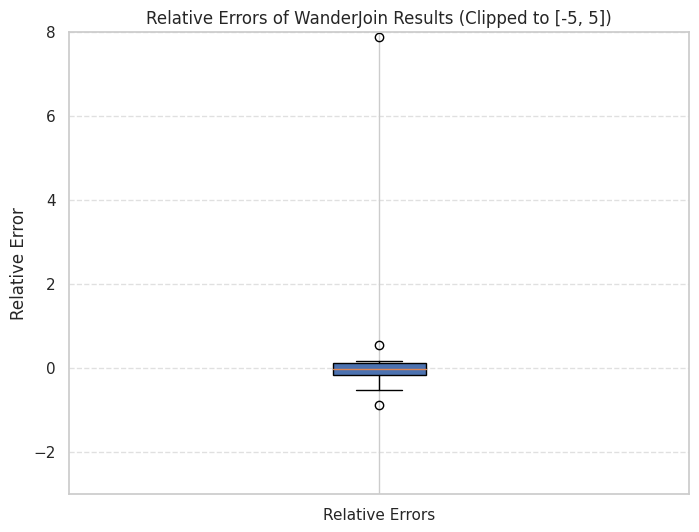

In [13]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# 文件路径（按需修改）
dataset= 'dataset_one'
true_path = Path("/home/wangshuo/resource/datasets/parler_data/dataset_one/ground_truth/T_true_ML1_oracle1_probability.txt")
# true_path = Path(f"/home/wangshuo/resource/datasets/parler_data/{dataset}/ground_truth/T_true.txt")
wander_join_results_path = Path(f"/home/wangshuo/resource/datasets/parler_data/{dataset}/results/wanderjoin_results.csv")

# 1. 读取真实结果（JSON 格式）
with open(true_path, "r") as f:
    try:
        true_results = json.load(f)
    except json.JSONDecodeError:
        # 如果不是严格 JSON（例如末尾有逗号），尝试更宽松解析
        txt = f.read().strip()
        txt = txt.rstrip(", \n\r")  # 去掉可能的尾逗号
        true_results = json.loads(txt)

# 2. 读取 WanderJoin 结果
wj_df = pd.read_csv(wander_join_results_path)

# 3. 计算相对误差
relative_errors = []
missing = []
for _, row in wj_df.iterrows():
    q = row.get("query_name")
    # 若在 CSV 中 query_name 没有后缀或格式不同，可在此做规范化：
    # q = q if q.endswith(".graph") else q + ".graph"
    try:
        T_hat = float(row["T_hat"])
    except Exception:
        # 尝试其他列名（如果有），否则跳过
        print(f"[Warning] 无法读取 T_hat，跳过行: {row.to_dict()}")
        continue

    if q in true_results:
        T_true = float(true_results[q])
        if T_true == 0:
            # 如果真实值为 0，定义相对误差为 nan 或特定值；这里跳过并告警
            print(f"[Warning] T_true 为 0，跳过: {q}")
            continue
        r = (T_hat - T_true) / T_true
        relative_errors.append(r)
    else:
        missing.append(q)

if missing:
    print(f"[Warning] 以下查询在真实值字典中未找到，将被忽略 ({len(missing)}): {missing}")

if not relative_errors:
    raise RuntimeError("没有计算到任何相对误差，请检查文件路径与字段名。")

# 4. 裁剪到 [-1, 1] 并绘图
relative_errors = np.array(relative_errors)
relative_errors_clipped = np.clip(relative_errors, -100, 100)

plt.figure(figsize=(8, 6))
plt.boxplot(relative_errors_clipped, vert=True, patch_artist=True, labels=["Relative Errors"])
plt.ylim(-3, 8)
plt.title("Relative Errors of WanderJoin Results (Clipped to [-5, 5])")
plt.ylabel("Relative Error")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

In [ ]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# 路径（按需修改）
true_path = Path("/home/wangshuo/resource/datasets/parler_data/dataset_one/ground_truth/T_true_ML1_oracle1_probability.txt")
wander_join_results_path = Path("/home/wangshuo/resource/datasets/parler_data/dataset_three/results/wanderjoin_results.csv")
outliers_csv_path = wander_join_results_path.with_name("wanderjoin_outliers.csv")

# 1. 读取真实结果（JSON 格式）
with open(true_path, "r") as f:
    true_results = json.load(f)

# 2. 读取 WanderJoin 结果
wj_df = pd.read_csv(wander_join_results_path)

# 3. 计算相对误差并构建分析表
rows = []
for _, row in wj_df.iterrows():
    q = row.get("query_name")
    try:
        T_hat = float(row.get("T_hat", np.nan))
    except Exception:
        T_hat = np.nan

    # 获取真实值（兼容 key 的微小差异）
    if q in true_results:
        T_true = float(true_results[q])
    else:
        # 尝试去掉路径或只取 basename
        q_basename = Path(str(q)).name
        T_true = float(true_results.get(q_basename, np.nan)) if q_basename in true_results else np.nan

    if np.isnan(T_hat) or np.isnan(T_true) or T_true == 0:
        rel_err = np.nan
    else:
        rel_err = (T_hat - T_true) / T_true

    # 尝试兼容不同结果列名
    walk_rate = row.get("walk_success_rate", row.get("success_rate", np.nan))
    struct_rate = row.get("struct_success_rate", row.get("struct_success", np.nan))

    rows.append({
        "query_name": q,
        "T_hat": T_hat,
        "T_true": T_true,
        "relative_error": rel_err,
        "walk_success_rate": walk_rate,
        "struct_success_rate": struct_rate
    })

df = pd.DataFrame(rows)

# 4. 识别奇异值（使用 IQR * 1.5）
valid_re = df["relative_error"].dropna()
if valid_re.empty:
    raise RuntimeError("没有可用的相对误差值，请检查数据和真实值映射。")

Q1 = valid_re.quantile(0.25)
Q3 = valid_re.quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# 也可以选择绝对阈值：例如 abs(relative_error) > 1
# 使用 IQR 判定
outliers_df = df[(df["relative_error"] < lower) | (df["relative_error"] > upper)].copy()

# 如果你更希望按绝对误差筛选，取消下面注释替换 outliers_df：
# outliers_df = df[df["relative_error"].abs() > 1.0].copy()

# 5. 输出 & 保存
if outliers_df.empty:
    print("未检测到基于 IQR 的奇异值（outliers）。")
else:
    # 选择需要输出的列并去重/排序
    out_cols = ["query_name", "T_true", "T_hat", "relative_error", "walk_success_rate", "struct_success_rate"]
    out = outliers_df[out_cols].sort_values(by="relative_error", key=lambda s: s.abs(), ascending=False)
    print("检测到以下奇异值（按 |relative_error| 降序）：")
    print(out.to_string(index=False))
    # 保存到 CSV
    out.to_csv(outliers_csv_path, index=False)
    print(f"\n奇异值详情已保存到: {outliers_csv_path}")

# 6. 绘图（原箱型图，仍将可视化时裁剪到 [-1,1]）
rel_arr = df["relative_error"].dropna().values
rel_clipped = np.clip(rel_arr, -10.0, 10.0)

plt.figure(figsize=(8, 6))
plt.boxplot(rel_clipped, vert=True, patch_artist=True, labels=["Relative Errors (clipped)"])
plt.ylim(-10, 10)
plt.title("Relative Errors of WanderJoin Results (clipped to [-1,1])")
plt.ylabel("Relative Error")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

In [ ]:
import os
import random
import json
import numpy as np
import pandas as pd
import networkx as nx
import collections
import matplotlib.pyplot as plt
from tqdm import tqdm
from typing import List, Dict, Tuple
from pathlib import Path

# ==========================================
# 1. 基础类定义 (保持不变，确保环境完整)
# ==========================================
class DataGraph:
    def __init__(self, filepath: str):
        self.adj = collections.defaultdict(list)
        self.labels = {}
        self.nodes_by_label = collections.defaultdict(list)
        self.adj_by_label = collections.defaultdict(lambda: collections.defaultdict(list))
        self.load_from_file(filepath)

    def load_from_file(self, filepath: str):
        if not os.path.exists(filepath):
            raise FileNotFoundError(f"Graph file not found: {filepath}")
        with open(filepath, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if not parts: continue
                if parts[0] == 'v':
                    vid, lbl = int(parts[1]), int(parts[2])
                    self.labels[vid] = lbl
                    self.nodes_by_label[lbl].append(vid)
                elif parts[0] == 'e':
                    u, v = int(parts[1]), int(parts[2])
                    self.adj[u].append(v)
                    self.adj[v].append(u)
        for u, neighbors in self.adj.items():
            for v in neighbors:
                self.adj_by_label[u][self.labels[v]].append(v)

    def get_neighbors_by_label(self, u: int, label: int) -> List[int]:
        return self.adj_by_label[u].get(label, [])

class PatternGraph:
    def __init__(self, filepath: str):
        self.G = nx.Graph()
        with open(filepath, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if not parts: continue
                if parts[0] == 'v':
                    self.G.add_node(int(parts[1]), label=int(parts[2]))
                elif parts[0] == 'e':
                    self.G.add_edge(int(parts[1]), int(parts[2]))
    @property
    def nodes(self): return self.G.nodes
    def neighbors(self, u): return self.G.neighbors(u)
    def number_of_nodes(self): return self.G.number_of_nodes()

class OracleManager:
    def __init__(self, dataset_path: str, 
                 oracle_col: str = "ML1_oracle1_probability", 
                 proxy_col: str = "ML1_proxy4b1_probability"):
        self.id_type_map = {}
        self.oracle_probs = {} # 用于最终验证 (Ground Truth Check)
        self.proxy_probs = {}  # 用于重要性采样权重 (Importance Sampling Weights)
        self.load_data(dataset_path, oracle_col, proxy_col)

    def load_data(self, dataset_path, oracle_col, proxy_col):
        idmap_path = os.path.join(dataset_path, "data_graph/id_mapping.csv")
        post_path = os.path.join(dataset_path, "csv_data/post.csv")
        
        # 1. 加载 ID 映射
        map_df = pd.read_csv(idmap_path, dtype=str)
        int_to_orig = {}
        for _, row in map_df.iterrows():
            iid = int(row['internal_id'])
            self.id_type_map[iid] = row['type']
            if row['type'] == 'Post': int_to_orig[iid] = row['orig_id']
        
        # 2. 加载 Post 概率 (同时读取 Oracle 和 Proxy)
        post_df = pd.read_csv(post_path, dtype=str)
        id_col = 'id:ID' if 'id:ID' in post_df.columns else post_df.columns[0]
        
        orig_to_oracle = {}
        orig_to_proxy = {}
        
        for _, row in post_df.iterrows():
            oid = row[id_col]
            # 读取 Oracle
            try: orig_to_oracle[oid] = float(row[oracle_col])
            except: orig_to_oracle[oid] = 0.0
            # 读取 Proxy
            try: orig_to_proxy[oid] = float(row[proxy_col])
            except: orig_to_proxy[oid] = 0.0 # 如果缺失，默认为0

        # 3. 映射回 internal_id
        for iid, oid in int_to_orig.items():
            if oid in orig_to_oracle: self.oracle_probs[iid] = orig_to_oracle[oid]
            if oid in orig_to_proxy: self.proxy_probs[iid] = orig_to_proxy[oid]

    def check_oracle(self, internal_id: int, threshold: float = 0.5) -> bool:
        """使用 Oracle 真值进行检查"""
        if internal_id not in self.oracle_probs:
            return self.id_type_map.get(internal_id) != 'Post'
        return self.oracle_probs[internal_id] > threshold

    def get_proxy_prob(self, internal_id: int) -> float:
        """获取 Proxy 预测概率"""
        return self.proxy_probs.get(internal_id, 0.0)
# ==========================================
# 2. 修改后的 WanderJoinSampler (支持重要性采样)
# ==========================================
class WanderJoinSampler:
    def __init__(self, data_graph, query_graph, oracle_manager):
        self.G = data_graph
        self.Q = query_graph
        self.oracle_manager = oracle_manager
        self.id_type_map = oracle_manager.id_type_map

    def get_matching_order(self) -> List[int]:
        return list(range(self.Q.number_of_nodes()))

    def get_node_weight(self, node_id: int) -> float:
        """
        计算节点的重要性权重: sqrt(proxy_prob)
        注意：这里必须使用 Proxy 的概率，而不是 Oracle 的概率
        """
        if self.id_type_map.get(node_id) != 'Post':
            return 1.0
        # 使用 Proxy 概率
        prob = self.oracle_manager.get_proxy_prob(node_id)
        # 避免概率为0导致权重为0（如果需要平滑可以加 1e-9，但 sqrt(0) 是合法的）
        return np.sqrt(prob)

    def single_walk(self, order: List[int], mode: str = 'uniform') -> Tuple[float, bool, Dict[int, int]]:
        mapping = {}
        used_data_nodes = set()
        walk_weight = 1.0
        
        for i, q_u in enumerate(order):
            target_label = self.Q.nodes[q_u]['label']
            
            # --- 1. 获取候选集 ---
            if i == 0:
                candidates = self.G.nodes_by_label.get(target_label, [])
            else:
                matched_q_neighbors = [n for n in self.Q.neighbors(q_u) if n in mapping]
                possible_v = None
                for q_neighbor in matched_q_neighbors:
                    v_prev = mapping[q_neighbor]
                    neighbors_subset = set(self.G.get_neighbors_by_label(v_prev, target_label))
                    if possible_v is None: possible_v = neighbors_subset
                    else: possible_v &= neighbors_subset
                    if not possible_v: break
                
                if possible_v: possible_v -= used_data_nodes
                candidates = list(possible_v) if possible_v else []

            if not candidates:
                return 0.0, False, {}

            # --- 2. 采样与权重更新 ---
            if mode == 'importance':
                # 重要性采样: 使用 Proxy 概率计算权重
                weights = [self.get_node_weight(v) for v in candidates]
                total_weight = sum(weights)
                
                if total_weight == 0:
                    # 如果所有候选节点的 Proxy 概率都为 0，则无法采样
                    return 0.0, False, {}
                
                # 按权重随机选择
                v_selected = random.choices(candidates, weights=weights, k=1)[0]
                w_selected = weights[candidates.index(v_selected)]
                
                # 更新估计值: 乘上 (总权重 / 选中节点权重)
                walk_weight *= (total_weight / w_selected)
                
            else:
                # 均匀采样
                v_selected = random.choice(candidates)
                walk_weight *= len(candidates)

            mapping[q_u] = v_selected
            used_data_nodes.add(v_selected)
                
        return walk_weight, True, mapping

    def check_oracle(self, mapping):
        """最终验证使用 Oracle 真值"""
        for d_node in mapping.values():
            if not self.oracle_manager.check_oracle(d_node, threshold=0.5):
                return False
        return True

    def estimate(self, num_walks: int = 1000, mode: str = 'uniform'):
        order = self.get_matching_order()
        total_est = 0.0
        success_cnt = 0
        
        for _ in range(num_walks):
            weight, struct_success, mapping = self.single_walk(order, mode=mode)
            
            if struct_success:
                # 只有通过 Oracle 检查的路径才计入总和
                if self.check_oracle(mapping):
                    total_est += weight
                    success_cnt += 1
                    
        return {
            "T_hat": total_est / num_walks,
            "success_rate": success_cnt / num_walks
        }


# ==========================================
# 3. 对比实验与绘图
# ==========================================
def run_comparison(dataset_name="dataset_two", num_walks=5000):
    base_path = f"/home/wangshuo/resource/datasets/parler_data/{dataset_name}"
    query_dir = os.path.join(base_path, "query_graph")
    data_graph_file = os.path.join(base_path, "data_graph/parler.graph")
    
    # 显式指定 Oracle 和 Proxy 列名
    oracle_col_name = "ML1_oracle1_probability"
    proxy_col_name = "ML1_proxy4b1_probability"
    true_file = os.path.join(base_path, f"ground_truth/T_true_{oracle_col_name}.txt") # 假设文件名包含列名，或者用 T_true.txt

    print(f"Dataset: {dataset_name}")
    print(f"Oracle Col: {oracle_col_name}")
    print(f"Proxy Col:  {proxy_col_name}")

    # 1. 加载数据
    print("Loading DataGraph & OracleManager...")
    DG = DataGraph(data_graph_file)
    
    # 初始化 OracleManager 时传入两列
    oracle = OracleManager(base_path, oracle_col=oracle_col_name, proxy_col=proxy_col_name)
    
    # 2. 加载真实值
    if not os.path.exists(true_file):
        # 尝试默认路径
        true_file = os.path.join(base_path, "ground_truth/T_true.txt")
        
    print(f"Loading True Values from: {true_file}")
    with open(true_file, 'r') as f:
        try: true_vals = json.load(f)
        except: true_vals = json.loads(f.read().strip().rstrip(','))

    query_files = sorted([f for f in os.listdir(query_dir) if f.endswith(".graph")])
    
    results_uniform = []
    results_importance = []
    
    print(f"Comparing on {len(query_files)} queries (N={num_walks})...")
    
    for q_file in tqdm(query_files):
        q_path = os.path.join(query_dir, q_file)
        try:
            QG = PatternGraph(q_path)
            sampler = WanderJoinSampler(DG, QG, oracle)
            
            # 获取真实值
            if q_file in true_vals: T_true = float(true_vals[q_file])
            else: continue
            if T_true == 0: continue

            # --- 运行 Uniform ---
            res_u = sampler.estimate(num_walks, mode='uniform')
            err_u = (res_u['T_hat'] - T_true) / T_true
            results_uniform.append(err_u)
            
            # --- 运行 Importance (使用 Proxy 概率) ---
            res_i = sampler.estimate(num_walks, mode='importance')
            err_i = (res_i['T_hat'] - T_true) / T_true
            results_importance.append(err_i)
            
        except Exception as e:
            print(f"Error on {q_file}: {e}")

    # 3. 绘制箱型图
    data = [
        np.clip(results_uniform, -1, 1), 
        np.clip(results_importance, -1, 1)
    ]
    
    plt.figure(figsize=(10, 6))
    plt.boxplot(data, labels=['Uniform Sampling', 'Importance Sampling (Proxy)'], patch_artist=True)
    plt.title(f"Relative Error Comparison (Clipped [-1, 1])\nDataset: {dataset_name}, Walks: {num_walks}")
    plt.ylabel("Relative Error")
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.axhline(0, color='red', linestyle='--', linewidth=1)
    plt.show()
    
    # 输出统计
    print(f"Uniform Mean Abs Error: {np.mean(np.abs(results_uniform)):.4f}")
    print(f"Importance Mean Abs Error: {np.mean(np.abs(results_importance)):.4f}")

# 运行对比
if __name__ == "__main__":
    run_comparison(dataset_name="dataset_one", num_walks=2000)

In [ ]:
import os
import random
import json
import numpy as np
import pandas as pd
import networkx as nx
import collections
import matplotlib.pyplot as plt
from tqdm import tqdm
from typing import List, Dict, Tuple
from pathlib import Path

# ==========================================
# 1. 基础类定义 (保持不变，确保环境完整)
# ==========================================
class DataGraph:
    def __init__(self, filepath: str):
        self.adj = collections.defaultdict(list)
        self.labels = {}
        self.nodes_by_label = collections.defaultdict(list)
        self.adj_by_label = collections.defaultdict(lambda: collections.defaultdict(list))
        self.load_from_file(filepath)

    def load_from_file(self, filepath: str):
        if not os.path.exists(filepath):
            raise FileNotFoundError(f"Graph file not found: {filepath}")
        with open(filepath, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if not parts: continue
                if parts[0] == 'v':
                    vid, lbl = int(parts[1]), int(parts[2])
                    self.labels[vid] = lbl
                    self.nodes_by_label[lbl].append(vid)
                elif parts[0] == 'e':
                    u, v = int(parts[1]), int(parts[2])
                    self.adj[u].append(v)
                    self.adj[v].append(u)
        for u, neighbors in self.adj.items():
            for v in neighbors:
                self.adj_by_label[u][self.labels[v]].append(v)

    def get_neighbors_by_label(self, u: int, label: int) -> List[int]:
        return self.adj_by_label[u].get(label, [])

class PatternGraph:
    def __init__(self, filepath: str):
        self.G = nx.Graph()
        with open(filepath, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if not parts: continue
                if parts[0] == 'v':
                    self.G.add_node(int(parts[1]), label=int(parts[2]))
                elif parts[0] == 'e':
                    self.G.add_edge(int(parts[1]), int(parts[2]))
    @property
    def nodes(self): return self.G.nodes
    def neighbors(self, u): return self.G.neighbors(u)
    def number_of_nodes(self): return self.G.number_of_nodes()

class OracleManager:
    def __init__(self, dataset_path: str, 
                 oracle_col: str = "ML1_oracle1_probability", 
                 proxy_col: str = "ML1_proxy4b1_probability"):
        self.id_type_map = {}
        self.oracle_probs = {} # 用于最终验证 (Ground Truth Check)
        self.proxy_probs = {}  # 用于重要性采样权重 (Importance Sampling Weights)
        self.load_data(dataset_path, oracle_col, proxy_col)

    def load_data(self, dataset_path, oracle_col, proxy_col):
        idmap_path = os.path.join(dataset_path, "data_graph/id_mapping.csv")
        post_path = os.path.join(dataset_path, "csv_data/post.csv")
        
        # 1. 加载 ID 映射
        map_df = pd.read_csv(idmap_path, dtype=str)
        int_to_orig = {}
        for _, row in map_df.iterrows():
            iid = int(row['internal_id'])
            self.id_type_map[iid] = row['type']
            if row['type'] == 'Post': int_to_orig[iid] = row['orig_id']
        
        # 2. 加载 Post 概率 (同时读取 Oracle 和 Proxy)
        post_df = pd.read_csv(post_path, dtype=str)
        id_col = 'id:ID' if 'id:ID' in post_df.columns else post_df.columns[0]
        
        orig_to_oracle = {}
        orig_to_proxy = {}
        
        for _, row in post_df.iterrows():
            oid = row[id_col]
            # 读取 Oracle
            try: orig_to_oracle[oid] = float(row[oracle_col])
            except: orig_to_oracle[oid] = 0.0
            # 读取 Proxy
            try: orig_to_proxy[oid] = float(row[proxy_col])
            except: orig_to_proxy[oid] = 0.0 # 如果缺失，默认为0

        # 3. 映射回 internal_id
        for iid, oid in int_to_orig.items():
            if oid in orig_to_oracle: self.oracle_probs[iid] = orig_to_oracle[oid]
            if oid in orig_to_proxy: self.proxy_probs[iid] = orig_to_proxy[oid]

    def check_oracle(self, internal_id: int, threshold: float = 0.5) -> bool:
        """使用 Oracle 真值进行检查"""
        if internal_id not in self.oracle_probs:
            return self.id_type_map.get(internal_id) != 'Post'
        return self.oracle_probs[internal_id] > threshold

    def get_proxy_prob(self, internal_id: int) -> float:
        """获取 Proxy 预测概率"""
        return self.proxy_probs.get(internal_id, 0.0)
# ==========================================
# 2. 修改后的 WanderJoinSampler (支持重要性采样)
# ==========================================
class WanderJoinSampler:
    def __init__(self, data_graph, query_graph, oracle_manager):
        self.G = data_graph
        self.Q = query_graph
        self.oracle_manager = oracle_manager
        self.id_type_map = oracle_manager.id_type_map

    def get_matching_order(self) -> List[int]:
        return list(range(self.Q.number_of_nodes()))

    def get_node_weight(self, node_id: int) -> float:
        """
        计算节点的重要性权重: sqrt(proxy_prob)
        注意：这里必须使用 Proxy 的概率，而不是 Oracle 的概率
        """
        if self.id_type_map.get(node_id) != 'Post':
            return 1.0
        # 使用 Proxy 概率
        prob = self.oracle_manager.get_proxy_prob(node_id)
        # 避免概率为0导致权重为0（如果需要平滑可以加 1e-9，但 sqrt(0) 是合法的）
        return np.sqrt(prob)

    def single_walk(self, order: List[int], mode: str = 'uniform') -> Tuple[float, bool, Dict[int, int]]:
        mapping = {}
        used_data_nodes = set()
        walk_weight = 1.0
        
        for i, q_u in enumerate(order):
            target_label = self.Q.nodes[q_u]['label']
            
            # --- 1. 获取候选集 ---
            if i == 0:
                candidates = self.G.nodes_by_label.get(target_label, [])
            else:
                matched_q_neighbors = [n for n in self.Q.neighbors(q_u) if n in mapping]
                possible_v = None
                for q_neighbor in matched_q_neighbors:
                    v_prev = mapping[q_neighbor]
                    neighbors_subset = set(self.G.get_neighbors_by_label(v_prev, target_label))
                    if possible_v is None: possible_v = neighbors_subset
                    else: possible_v &= neighbors_subset
                    if not possible_v: break
                
                if possible_v: possible_v -= used_data_nodes
                candidates = list(possible_v) if possible_v else []

            if not candidates:
                return 0.0, False, {}

            # --- 2. 采样与权重更新 ---
            if mode == 'importance':
                # 重要性采样: 使用 Proxy 概率计算权重
                weights = [self.get_node_weight(v) for v in candidates]
                total_weight = sum(weights)
                
                if total_weight == 0:
                    # 如果所有候选节点的 Proxy 概率都为 0，则无法采样
                    return 0.0, False, {}
                
                # 按权重随机选择
                v_selected = random.choices(candidates, weights=weights, k=1)[0]
                w_selected = weights[candidates.index(v_selected)]
                
                # 更新估计值: 乘上 (总权重 / 选中节点权重)
                walk_weight *= (total_weight / w_selected)
                
            else:
                # 均匀采样
                v_selected = random.choice(candidates)
                walk_weight *= len(candidates)

            mapping[q_u] = v_selected
            used_data_nodes.add(v_selected)
                
        return walk_weight, True, mapping

    def check_oracle(self, mapping):
        """最终验证使用 Oracle 真值"""
        for d_node in mapping.values():
            if not self.oracle_manager.check_oracle(d_node, threshold=0.5):
                return False
        return True

    def estimate(self, num_walks: int = 1000, mode: str = 'uniform'):
        order = self.get_matching_order()
        total_est = 0.0
        success_cnt = 0
        
        for _ in range(num_walks):
            weight, struct_success, mapping = self.single_walk(order, mode=mode)
            
            if struct_success:
                # 只有通过 Oracle 检查的路径才计入总和
                if self.check_oracle(mapping):
                    total_est += weight
                    success_cnt += 1
                    
        return {
            "T_hat": total_est / num_walks,
            "success_rate": success_cnt / num_walks
        }


# ==========================================
# 3. 对比实验与绘图
# ==========================================
def run_comparison(dataset_name="dataset_two", num_walks=5000):
    base_path = f"/home/wangshuo/resource/datasets/parler_data/{dataset_name}"
    query_dir = os.path.join(base_path, "query_graph")
    data_graph_file = os.path.join(base_path, "data_graph/parler.graph")
    
    # 显式指定 Oracle 和 Proxy 列名
    oracle_col_name = "ML1_oracle1_probability"
    proxy_col_name = "ML1_proxy4b1_probability"
    true_file = os.path.join(base_path, f"ground_truth/T_true_{oracle_col_name}.txt") # 假设文件名包含列名，或者用 T_true.txt

    print(f"Dataset: {dataset_name}")
    print(f"Oracle Col: {oracle_col_name}")
    print(f"Proxy Col:  {proxy_col_name}")

    # 1. 加载数据
    print("Loading DataGraph & OracleManager...")
    DG = DataGraph(data_graph_file)
    
    # 初始化 OracleManager 时传入两列
    oracle = OracleManager(base_path, oracle_col=oracle_col_name, proxy_col=proxy_col_name)
    
    # 2. 加载真实值
    if not os.path.exists(true_file):
        # 尝试默认路径
        true_file = os.path.join(base_path, "ground_truth/T_true.txt")
        
    print(f"Loading True Values from: {true_file}")
    with open(true_file, 'r') as f:
        try: true_vals = json.load(f)
        except: true_vals = json.loads(f.read().strip().rstrip(','))

    query_files = sorted([f for f in os.listdir(query_dir) if f.endswith(".graph")])
    
    results_uniform = []
    results_importance = []
    
    print(f"Comparing on {len(query_files)} queries (N={num_walks})...")
    
    for q_file in tqdm(query_files):
        q_path = os.path.join(query_dir, q_file)
        try:
            QG = PatternGraph(q_path)
            sampler = WanderJoinSampler(DG, QG, oracle)
            
            # 获取真实值
            if q_file in true_vals: T_true = float(true_vals[q_file])
            else: continue
            if T_true == 0: continue

            # --- 运行 Uniform ---
            res_u = sampler.estimate(num_walks, mode='uniform')
            err_u = (res_u['T_hat'] - T_true) / T_true
            results_uniform.append(err_u)
            
            # --- 运行 Importance (使用 Proxy 概率) ---
            res_i = sampler.estimate(num_walks, mode='importance')
            err_i = (res_i['T_hat'] - T_true) / T_true
            results_importance.append(err_i)
            
        except Exception as e:
            print(f"Error on {q_file}: {e}")

    # 3. 绘制箱型图
    data = [
        np.clip(results_uniform, -1, 1), 
        np.clip(results_importance, -1, 1)
    ]
    
    plt.figure(figsize=(10, 6))
    plt.boxplot(data, labels=['Uniform Sampling', 'Importance Sampling (Proxy)'], patch_artist=True)
    plt.title(f"Relative Error Comparison (Clipped [-1, 1])\nDataset: {dataset_name}, Walks: {num_walks}")
    plt.ylabel("Relative Error")
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.axhline(0, color='red', linestyle='--', linewidth=1)
    plt.show()
    
    # 输出统计
    print(f"Uniform Mean Abs Error: {np.mean(np.abs(results_uniform)):.4f}")
    print(f"Importance Mean Abs Error: {np.mean(np.abs(results_importance)):.4f}")

# 运行对比
if __name__ == "__main__":
    run_comparison(dataset_name="dataset_one", num_walks=2000)

随机游走 + 重要性采样方法对比

In [ ]:
import os
import random
import json
import numpy as np
import pandas as pd
import networkx as nx
import collections
import matplotlib.pyplot as plt
from tqdm import tqdm
from typing import List, Dict, Tuple
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
# ==========================================
# 1. 基础类定义 (DataGraph 优化版)
# ==========================================
class DataGraph:
    def __init__(self, filepath: str):
        self.adj = collections.defaultdict(list)
        self.labels = {}
        self.nodes_by_label = collections.defaultdict(list)
        # 优化索引: adj_label[u][target_label] -> [v1, v2...]
        self.adj_by_label = collections.defaultdict(lambda: collections.defaultdict(list))
        self.load_from_file(filepath)

    def load_from_file(self, filepath: str):
        if not os.path.exists(filepath):
            raise FileNotFoundError(f"Graph file not found: {filepath}")
        
        print(f"[DataGraph] Reading raw file: {filepath}")
        with open(filepath, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if not parts: continue
                if parts[0] == 'v':
                    vid, lbl = int(parts[1]), int(parts[2])
                    self.labels[vid] = lbl
                    self.nodes_by_label[lbl].append(vid)
                elif parts[0] == 'e':
                    u, v = int(parts[1]), int(parts[2])
                    self.adj[u].append(v)
                    self.adj[v].append(u)
        
        print("[DataGraph] Building label indices (Progress bar)...")
        # 使用 tqdm 显示进度，避免看起来像卡死
        for u, neighbors in tqdm(self.adj.items(), desc="Indexing Edges"):
            for v in neighbors:
                if v in self.labels:
                    self.adj_by_label[u][self.labels[v]].append(v)
        print("[DataGraph] Ready.")

    def get_neighbors_by_label(self, u: int, label: int) -> List[int]:
        return self.adj_by_label[u].get(label, [])

class PatternGraph:
    def __init__(self, filepath: str):
        self.G = nx.Graph()
        with open(filepath, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if not parts: continue
                if parts[0] == 'v':
                    self.G.add_node(int(parts[1]), label=int(parts[2]))
                elif parts[0] == 'e':
                    self.G.add_edge(int(parts[1]), int(parts[2]))
    @property
    def nodes(self): return self.G.nodes
    def neighbors(self, u): return self.G.neighbors(u)
    def number_of_nodes(self): return self.G.number_of_nodes()

# ==========================================
# 2. OracleManager (优化版，向量化加载)
# ==========================================
class OracleManager:
    def __init__(self, dataset_path: str, 
                 oracle_col: str = "ML1_oracle1_probability", 
                 proxy_col: str = "ML1_proxy4b1_probability"):
        self.id_type_map = {}
        self.oracle_probs = {} 
        self.proxy_probs = {}  
        self.load_data(dataset_path, oracle_col, proxy_col)

    def load_data(self, dataset_path, oracle_col, proxy_col):
        idmap_path = os.path.join(dataset_path, "data_graph/id_mapping.csv")
        post_path = os.path.join(dataset_path, "csv_data/post.csv")
        
        print("[OracleManager] Loading ID Mapping...")
        map_df = pd.read_csv(idmap_path, dtype={'internal_id': int, 'orig_id': str, 'type': str}, usecols=['internal_id', 'orig_id', 'type'])
        
        # 只保留 Post 类型的映射，减少内存
        post_map_df = map_df[map_df['type'] == 'Post'][['internal_id', 'orig_id']]
        # 保存 type map 用于检查
        self.id_type_map = dict(zip(map_df['internal_id'], map_df['type']))

        print("[OracleManager] Loading Post Data (Vectorized)...")
        try:
            # 只读取需要的列，加速加载
            header = pd.read_csv(post_path, nrows=0)
            id_col = 'id:ID' if 'id:ID' in header.columns else header.columns[0]
            
            post_df = pd.read_csv(post_path, usecols=[id_col, oracle_col, proxy_col], dtype={id_col: str})
            
            # 使用 Merge 代替循环，极快
            merged = pd.merge(post_map_df, post_df, left_on='orig_id', right_on=id_col, how='left')
            
            # 填充 NaN 并转换为字典
            merged[oracle_col] = pd.to_numeric(merged[oracle_col], errors='coerce').fillna(0.0)
            merged[proxy_col] = pd.to_numeric(merged[proxy_col], errors='coerce').fillna(0.0)
            
            self.oracle_probs = dict(zip(merged['internal_id'], merged[oracle_col]))
            self.proxy_probs = dict(zip(merged['internal_id'], merged[proxy_col]))
            
            print(f"[OracleManager] Loaded {len(self.oracle_probs)} probabilities.")
            
        except Exception as e:
            print(f"[Error] Failed to load post.csv: {e}")

    def check_oracle(self, internal_id: int, threshold: float = 0.5) -> bool:
        if internal_id not in self.oracle_probs:
            # 如果不是 Post，默认返回 True (假设 Comment 等没有过滤条件)
            # 或者根据具体需求修改
            return self.id_type_map.get(internal_id) != 'Post'
        return self.oracle_probs[internal_id] > threshold

    def get_proxy_prob(self, internal_id: int) -> float:
        return self.proxy_probs.get(internal_id, 0.0)

# ==========================================
# 3. 修改后的 WanderJoinSampler (核心修改)
# ==========================================
class WanderJoinSampler:
    # 定义需要重要性采样的标签
    POST_LABEL = 1 

    def __init__(self, data_graph, query_graph, oracle_manager):
        self.G = data_graph
        self.Q = query_graph
        self.oracle_manager = oracle_manager
        self.id_type_map = oracle_manager.id_type_map

    def get_matching_order(self) -> List[int]:
        # 简单 BFS 序，保证连通性
        start_node = 0
        order = []
        visited = set()
        queue = [start_node]
        visited.add(start_node)
        while queue:
            u = queue.pop(0)
            order.append(u)
            for v in sorted(self.Q.neighbors(u)):
                if v not in visited:
                    visited.add(v)
                    queue.append(v)
        return order

    def get_node_weight(self, node_id: int) -> float:
        """
        仅获取 Post 节点的 Proxy 权重。
        """
        # 注意：这里假设调用者已经判断了标签为 1
        prob = self.oracle_manager.get_proxy_prob(node_id)
        # sqrt 平滑
        return np.sqrt(prob)

    def single_walk(self, order: List[int], mode: str = 'uniform') -> Tuple[float, bool, Dict[int, int]]:
        mapping = {}
        used_data_nodes = set()
        walk_weight = 1.0
        
        for i, q_u in enumerate(order):
            target_label = self.Q.nodes[q_u]['label']
            
            # --- 1. 获取候选集 (不变) ---
            if i == 0:
                candidates = self.G.nodes_by_label.get(target_label, [])
            else:
                matched_q_neighbors = [n for n in self.Q.neighbors(q_u) if n in mapping]
                possible_v = None
                for q_neighbor in matched_q_neighbors:
                    v_prev = mapping[q_neighbor]
                    neighbors_subset = set(self.G.get_neighbors_by_label(v_prev, target_label))
                    if possible_v is None: possible_v = neighbors_subset
                    else: possible_v &= neighbors_subset
                    if not possible_v: break
                
                if possible_v: possible_v -= used_data_nodes
                candidates = list(possible_v) if possible_v else []

            if not candidates:
                return 0.0, False, {}

            # --- 2. 采样逻辑 (核心修改) ---
            
            # 判断条件：模式为 importance 且 当前查询节点标签为 POST_LABEL (1)
            # 只有满足这两个条件，才进行加权采样
            if mode == 'importance' and target_label == self.POST_LABEL:
                
                # --- 重要性采样逻辑 ---
                weights = [self.get_node_weight(v) for v in candidates]
                total_weight = sum(weights)
                
                if total_weight == 0:
                    # 如果所有候选 Proxy 都是 0，无法采样，路径失败
                    return 0.0, False, {}
                
                # 使用 numpy 进行高效加权采样
                # 归一化
                probs = np.array(weights) / total_weight
                
                # 采样一个
                idx = np.random.choice(len(candidates), p=probs)
                v_selected = candidates[idx]
                w_selected = weights[idx]
                
                # 更新估计值 (Horvitz-Thompson):
                # 原始均匀概率 = 1/N
                # 新的概率 = w_v / W_total
                # 调整系数 = (1/新概率) = W_total / w_v
                walk_weight *= (total_weight / w_selected)
                
            else:
                # --- 均匀采样逻辑 (Comment 或 Uniform 模式) ---
                # 也就是 target_label != 1 或者 mode == 'uniform'
                v_selected = random.choice(candidates)
                
                # 均匀采样的权重 = 候选集大小 N
                walk_weight *= len(candidates)

            mapping[q_u] = v_selected
            used_data_nodes.add(v_selected)
                
        return walk_weight, True, mapping

    def check_oracle(self, mapping):
        for d_node in mapping.values():
            if not self.oracle_manager.check_oracle(d_node, threshold=0.5):
                return False
        return True

    def estimate(self, num_walks: int = 1000, mode: str = 'uniform'):
        order = self.get_matching_order()
        total_est = 0.0
        success_cnt = 0
        
        # 使用 tqdm 显示进度，避免“卡住”的感觉
        for _ in range(num_walks): # 若 num_walks 很大建议加 tqdm(range(num_walks))
            weight, struct_success, mapping = self.single_walk(order, mode=mode)
            
            if struct_success:
                # 只有通过 Oracle 检查的路径才计入总和
                if self.check_oracle(mapping):
                    total_est += weight
                    success_cnt += 1
                    
        return {
            "T_hat": total_est / num_walks,
            "success_rate": success_cnt / num_walks
        }

def batch_evaluate(dataset_name="dataset_one", num_walks=1000):
    # --- 1. 路径配置 ---
    base_path = f"/home/wangshuo/resource/datasets/parler_data/{dataset_name}"
    query_dir = os.path.join(base_path, "query_graph")
    data_graph_file = os.path.join(base_path, "data_graph/parler.graph")
    # 假设 T_true 文件是 JSON 格式 (key: query_name, value: count)
    true_file = os.path.join(base_path, "ground_truth/T_true_ML1_oracle1_probability.txt") 
    
    output_csv = f"wanderjoin_comparison_{dataset_name}.csv"

    # --- 2. 加载静态资源 (只加载一次) ---
    print(f"====== Batch Evaluation: {dataset_name} ======")
    print(">>> 1. Loading Data Graph...")
    if not os.path.exists(data_graph_file):
        print(f"[Error] Data graph not found: {data_graph_file}")
        return None
    DG = DataGraph(data_graph_file)
    
    print(">>> 2. Loading Oracle Manager...")
    # 确保列名与你的 CSV 一致
    oracle = OracleManager(base_path, oracle_col="ML1_oracle1_probability", proxy_col="ML1_proxy4b1_probability")
    
    print(f">>> 3. Loading Ground Truth from {true_file}...")
    if not os.path.exists(true_file):
        print("[Error] T_true file not found.")
        return None
    
    with open(true_file, 'r') as f:
        true_vals = json.load(f)

    # 获取所有查询文件
    query_files = sorted([f for f in os.listdir(query_dir) if f.endswith(".graph")])
    print(f">>> Found {len(query_files)} queries. Starting comparison (Walks={num_walks})...")
    
    records = []

    # --- 3. 循环评估 ---
    for q_file in tqdm(query_files, desc="Evaluating"):
        # 匹配 T_true 中的 Key (处理可能的扩展名差异)
        # 尝试完整文件名
        if q_file in true_vals:
            T_true = float(true_vals[q_file])
        # 尝试去掉 .graph 后缀
        elif q_file.replace(".graph", "") in true_vals:
            T_true = float(true_vals[q_file.replace(".graph", "")])
        else:
            # 如果找不到真实值，跳过
            continue
            
        if T_true == 0: continue # 忽略真实值为 0 的查询

        q_path = os.path.join(query_dir, q_file)
        
        try:
            # 构建查询图和采样器
            QG = PatternGraph(q_path)
            sampler = WanderJoinSampler(DG, QG, oracle)
            
            # --- 方法 A: 均匀采样 (Uniform) ---
            res_u = sampler.estimate(num_walks, mode='uniform')
            est_u = res_u['T_hat']
            # 计算相对误差: (Est - True) / True
            err_u = (est_u - T_true) / T_true
            
            records.append({
                "Query": q_file,
                "Method": "Uniform",
                "T_True": T_true,
                "T_Hat": est_u,
                "RelativeError": err_u,
                "AbsRelativeError": abs(err_u),
                "SuccessRate": res_u['success_rate']
            })
            
            # --- 方法 B: 重要性采样 (Importance - Post Only) ---
            res_i = sampler.estimate(num_walks, mode='importance')
            est_i = res_i['T_hat']
            err_i = (est_i - T_true) / T_true
            
            records.append({
                "Query": q_file,
                "Method": "Importance (Post)",
                "T_True": T_true,
                "T_Hat": est_i,
                "RelativeError": err_i,
                "AbsRelativeError": abs(err_i),
                "SuccessRate": res_i['success_rate']
            })
            
        except Exception as e:
            print(f"[Warn] Failed on {q_file}: {e}")

    # --- 4. 保存结果 ---
    df = pd.DataFrame(records)
    if not df.empty:
        df.to_csv(output_csv, index=False)
        print(f"\n>>> Results saved to {output_csv}")
        return df
    else:
        print("No results generated.")
        return None

# ==========================================
# 6. 绘图函数
# ==========================================
def plot_results(df):
    if df is None or df.empty:
        print("No data to plot.")
        return

    # 设置绘图风格
    sns.set(style="whitegrid")
    
    # --- 图 1: 相对误差箱型图 ---
    plt.figure(figsize=(10, 6))
    
    # 为了防止极端的离群值破坏图表可读性，通常限制 Y 轴范围或去除离群点
    # 这里我们展示原始分布，但也计算去除离群点后的均值
    
    sns.boxplot(x="Method", y="RelativeError", data=df, showfliers=False, width=0.5, palette="Set2")
    plt.axhline(0, color='red', linestyle='--', linewidth=1, label="Perfect Estimate")
    plt.title("Relative Error Distribution (WanderJoin: Uniform vs Importance)")
    plt.ylabel("(Estimated - True) / True")
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    # --- 图 2: 绝对误差条形图 (更直观的对比) ---
    # 计算每种方法的平均绝对误差 (MAPE)
    mape = df.groupby("Method")["AbsRelativeError"].mean().reset_index()
    
    plt.figure(figsize=(8, 5))
    ax = sns.barplot(x="Method", y="AbsRelativeError", data=mape, palette="viridis")
    plt.title("Mean Absolute Percentage Error (MAPE)")
    plt.ylabel("Average |Relative Error|")
    
    # 在柱子上显示数值
    for p in ax.patches:
        height = p.get_height()
        ax.text(p.get_x() + p.get_width()/2., height + 0.01,
                f'{height:.4f}', ha="center")
    
    plt.tight_layout()
    plt.show()

    # --- 打印统计摘要 ---
    print("\n====== Statistical Summary ======")
    stats = df.groupby("Method")["AbsRelativeError"].describe()
    print(stats)

# ==========================================
# 7. 主执行入口
# ==========================================
if __name__ == "__main__":
    # 1. 运行批处理评估
    # 根据你的机器性能调整 num_walks，越多越准但越慢
    df_results = batch_evaluate(dataset_name="dataset_one", num_walks=20000)
    
    # 2. 绘制对比图
    plot_results(df_results)

In [ ]:
import os
import random
import json
import numpy as np
import pandas as pd
import networkx as nx
import collections
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from typing import List, Dict, Tuple

# ==========================================
# 1. 基础类定义 (DataGraph 优化版)
# ==========================================
class DataGraph:
    def __init__(self, filepath: str):
        self.adj = collections.defaultdict(list)
        self.labels = {}
        self.nodes_by_label = collections.defaultdict(list)
        # 优化索引: adj_label[u][target_label] -> [v1, v2...]
        self.adj_by_label = collections.defaultdict(lambda: collections.defaultdict(list))
        self.load_from_file(filepath)

    def load_from_file(self, filepath: str):
        if not os.path.exists(filepath):
            raise FileNotFoundError(f"Graph file not found: {filepath}")
        
        print(f"[DataGraph] Reading raw file: {filepath}")
        with open(filepath, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if not parts: continue
                if parts[0] == 'v':
                    vid, lbl = int(parts[1]), int(parts[2])
                    self.labels[vid] = lbl
                    self.nodes_by_label[lbl].append(vid)
                elif parts[0] == 'e':
                    u, v = int(parts[1]), int(parts[2])
                    self.adj[u].append(v)
                    self.adj[v].append(u)
        
        print("[DataGraph] Building label indices (Progress bar)...")
        # 使用 tqdm 显示进度
        for u, neighbors in tqdm(self.adj.items(), desc="Indexing Edges"):
            for v in neighbors:
                if v in self.labels:
                    self.adj_by_label[u][self.labels[v]].append(v)
        print("[DataGraph] Ready.")

    def get_neighbors_by_label(self, u: int, label: int) -> List[int]:
        return self.adj_by_label[u].get(label, [])

class PatternGraph:
    def __init__(self, filepath: str):
        self.G = nx.Graph()
        with open(filepath, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if not parts: continue
                if parts[0] == 'v':
                    self.G.add_node(int(parts[1]), label=int(parts[2]))
                elif parts[0] == 'e':
                    self.G.add_edge(int(parts[1]), int(parts[2]))
    @property
    def nodes(self): return self.G.nodes
    def neighbors(self, u): return self.G.neighbors(u)
    def number_of_nodes(self): return self.G.number_of_nodes()

# ==========================================
# 2. OracleManager (优化版，向量化加载)
# ==========================================
class OracleManager:
    def __init__(self, dataset_path: str, 
                 oracle_col: str = "ML1_oracle1_probability", 
                 proxy_col: str = "ML1_proxy4b1_probability"):
        self.id_type_map = {}
        self.oracle_probs = {} 
        self.proxy_probs = {}  
        self.load_data(dataset_path, oracle_col, proxy_col)

    def load_data(self, dataset_path, oracle_col, proxy_col):
        idmap_path = os.path.join(dataset_path, "data_graph/id_mapping.csv")
        post_path = os.path.join(dataset_path, "csv_data/post.csv")
        
        print("[OracleManager] Loading ID Mapping...")
        # 1. 加载 ID 映射 (只保留 Post 类型)
        map_df = pd.read_csv(idmap_path, dtype={'internal_id': int, 'orig_id': str, 'type': str}, usecols=['internal_id', 'orig_id', 'type'])
        
        # 保存 type map
        self.id_type_map = dict(zip(map_df['internal_id'], map_df['type']))
        
        # 只保留 Post 类型的映射用于合并
        post_map_df = map_df[map_df['type'] == 'Post'][['internal_id', 'orig_id']]

        print("[OracleManager] Loading Post Data (Vectorized)...")
        try:
            # 2. 加载 Post 数据
            header = pd.read_csv(post_path, nrows=0)
            id_col = 'id:ID' if 'id:ID' in header.columns else header.columns[0]
            
            # 读取
            post_df = pd.read_csv(post_path, usecols=[id_col, oracle_col, proxy_col], dtype={id_col: str})
            
            # 3. 使用 Merge 代替循环
            print("[OracleManager] Merging Data...")
            merged = pd.merge(post_map_df, post_df, left_on='orig_id', right_on=id_col, how='left')
            
            # 4. 填充 NaN 并转换为字典
            merged[oracle_col] = pd.to_numeric(merged[oracle_col], errors='coerce').fillna(0.0)
            merged[proxy_col] = pd.to_numeric(merged[proxy_col], errors='coerce').fillna(0.0)
            
            self.oracle_probs = dict(zip(merged['internal_id'], merged[oracle_col]))
            self.proxy_probs = dict(zip(merged['internal_id'], merged[proxy_col]))
            
            print(f"[OracleManager] Loaded {len(self.oracle_probs)} probabilities.")
            
        except Exception as e:
            print(f"[Error] Failed to load post.csv: {e}")

    def check_oracle(self, internal_id: int, threshold: float = 0.5) -> bool:
        if internal_id not in self.oracle_probs:
            return self.id_type_map.get(internal_id) != 'Post'
        return self.oracle_probs[internal_id] > threshold

    def get_proxy_prob(self, internal_id: int) -> float:
        return self.proxy_probs.get(internal_id, 0.0)

# ==========================================
# 3. 修改后的 WanderJoinSampler (核心修改)
# ==========================================
class WanderJoinSampler:
    # 定义需要重要性采样的标签 (Post)
    POST_LABEL = 1 

    def __init__(self, data_graph, query_graph, oracle_manager):
        self.G = data_graph
        self.Q = query_graph
        self.oracle_manager = oracle_manager
        self.id_type_map = oracle_manager.id_type_map

    def get_matching_order(self) -> List[int]:
        start_node = 0
        order = []
        visited = set()
        queue = [start_node]
        visited.add(start_node)
        while queue:
            u = queue.pop(0)
            order.append(u)
            for v in sorted(self.Q.neighbors(u)):
                if v not in visited:
                    visited.add(v)
                    queue.append(v)
        return order

    def get_node_weight(self, node_id: int) -> float:
        prob = self.oracle_manager.get_proxy_prob(node_id)
        return np.sqrt(prob) # sqrt 平滑

    def single_walk(self, order: List[int], mode: str = 'uniform') -> Tuple[float, bool, Dict[int, int]]:
        mapping = {}
        used_data_nodes = set()
        walk_weight = 1.0
        
        for i, q_u in enumerate(order):
            target_label = self.Q.nodes[q_u]['label']
            
            # --- 1. 获取候选集 ---
            if i == 0:
                candidates = self.G.nodes_by_label.get(target_label, [])
            else:
                matched_q_neighbors = [n for n in self.Q.neighbors(q_u) if n in mapping]
                possible_v = None
                for q_neighbor in matched_q_neighbors:
                    v_prev = mapping[q_neighbor]
                    neighbors_subset = set(self.G.get_neighbors_by_label(v_prev, target_label))
                    if possible_v is None: possible_v = neighbors_subset
                    else: possible_v &= neighbors_subset
                    if not possible_v: break
                
                if possible_v: possible_v -= used_data_nodes
                candidates = list(possible_v) if possible_v else []

            if not candidates:
                return 0.0, False, {}

            # --- 2. 采样逻辑 (优化：NumPy 加速) ---
            if mode == 'importance' and target_label == self.POST_LABEL:
                # 批量计算权重
                weights = np.array([self.get_node_weight(v) for v in candidates])
                total_weight = np.sum(weights)
                
                if total_weight == 0:
                    return 0.0, False, {}
                
                # 归一化概率
                probs = weights / total_weight
                
                # 使用 numpy.random.choice 采样索引
                idx = np.random.choice(len(candidates), p=probs)
                
                v_selected = candidates[idx]
                w_selected = weights[idx]
                
                # 更新估计值 (Horvitz-Thompson)
                walk_weight *= (total_weight / w_selected)
                
            else:
                # 均匀采样逻辑
                v_selected = random.choice(candidates)
                walk_weight *= len(candidates)

            mapping[q_u] = v_selected
            used_data_nodes.add(v_selected)
                
        return walk_weight, True, mapping

    def check_oracle(self, mapping):
        for d_node in mapping.values():
            if not self.oracle_manager.check_oracle(d_node, threshold=0.5):
                return False
        return True

    def estimate(self, num_walks: int = 1000, mode: str = 'uniform'):
        order = self.get_matching_order()
        total_est = 0.0
        success_cnt = 0
        
        # 统计唯一 Post 节点 (采样开销)
        sampled_post_nodes = set()
        
        for _ in range(num_walks): 
            weight, struct_success, mapping = self.single_walk(order, mode=mode)
            
            if struct_success:
                # 记录 Post 节点
                for node_id in mapping.values():
                    if self.id_type_map.get(node_id) == 'Post':
                        sampled_post_nodes.add(node_id)

                if self.check_oracle(mapping):
                    total_est += weight
                    success_cnt += 1
                    
        return {
            "T_hat": total_est / num_walks,
            "success_rate": success_cnt / num_walks,
            "unique_post_count": len(sampled_post_nodes) # 返回统计结果
        }

# ==========================================
# 5. 批处理函数 (Batch Processing)
# ==========================================
def batch_evaluate(dataset_name="dataset_one", num_walks=1000):
    # --- 1. 路径配置 ---
    base_path = f"/home/wangshuo/resource/datasets/parler_data/{dataset_name}"
    query_dir = os.path.join(base_path, "query_graph")
    data_graph_file = os.path.join(base_path, "data_graph/parler.graph")
    true_file = os.path.join(base_path, "ground_truth/T_true_ML1_oracle1_probability.txt") 
    
    output_csv = f"wanderjoin_comparison_{dataset_name}.csv"

    # --- 2. 加载静态资源 ---
    print(f"====== Batch Evaluation: {dataset_name} ======")
    print(">>> 1. Loading Data Graph...")
    if not os.path.exists(data_graph_file):
        print(f"[Error] Data graph not found: {data_graph_file}")
        return None
    DG = DataGraph(data_graph_file)
    
    print(">>> 2. Loading Oracle Manager...")
    oracle = OracleManager(base_path, oracle_col="ML1_oracle1_probability", proxy_col="ML1_proxy4b1_probability")
    
    print(f">>> 3. Loading Ground Truth from {true_file}...")
    if not os.path.exists(true_file):
        print("[Error] T_true file not found.")
        return None
    
    try:
        with open(true_file, 'r') as f:
            true_vals = json.load(f)
    except Exception as e:
        print(f"[Error] JSON load failed: {e}")
        return None

    query_files = sorted([f for f in os.listdir(query_dir) if f.endswith(".graph")])
    print(f">>> Found {len(query_files)} queries. Starting comparison (Walks={num_walks})...")
    
    records = []

    # --- 3. 循环评估 ---
    for q_file in tqdm(query_files, desc="Evaluating"):
        print(f"Processing query: {q_file}")  # 输出当前处理的查询名字
        if q_file in true_vals:
            T_true = float(true_vals[q_file])
        elif q_file.replace(".graph", "") in true_vals:
            T_true = float(true_vals[q_file.replace(".graph", "")])
        else:
            continue
            
        if T_true == 0: continue 

        q_path = os.path.join(query_dir, q_file)
        
        try:
            QG = PatternGraph(q_path)
            sampler = WanderJoinSampler(DG, QG, oracle)
            
            # --- 方法 A: 均匀采样 (Uniform) ---
            res_u = sampler.estimate(num_walks, mode='uniform')
            est_u = res_u['T_hat']
            err_u = (est_u - T_true) / T_true
            
            records.append({
                "query_basename": q_file,
                "method": "Uniform",
                "T_true": T_true,
                "T_hat": est_u,
                "Qerror": err_u,
                "AbsRelativeError": abs(err_u),
                "SuccessRate": res_u['success_rate'],
                "n_post": res_u['unique_post_count']
            })
            
            # --- 方法 B: 重要性采样 (Importance - Post Only) ---
            res_i = sampler.estimate(num_walks, mode='importance')
            est_i = res_i['T_hat']
            err_i = (est_i - T_true) / T_true
            
            records.append({
                "query_basename": q_file,
                "method": "Importance (Post)",
                "T_true": T_true,
                "T_hat": est_i,
                "Qerror": err_i,
                "AbsRelativeError": abs(err_i),
                "SuccessRate": res_i['success_rate'],
                "n_post": res_i['unique_post_count']
            })
            
        except Exception as e:
            print(f"[Warn] Failed on {q_file}: {e}")

    # --- 4. 保存结果 ---
    df = pd.DataFrame(records)
    if not df.empty:
        df.to_csv(output_csv, index=False)
        print(f"\n>>> Results saved to {output_csv}")
        return df
    else:
        print("No results generated.")
        return None

# ==========================================
# 6. 绘图函数
# ==========================================
def plot_results(df):
    if df is None or df.empty:
        print("No data to plot.")
        return

    # 设置绘图风格
    sns.set(style="whitegrid")
    
    # --- 图 1: 相对误差箱型图 ---
    plt.figure(figsize=(10, 6))
    sns.boxplot(x="method", y="Qerror", data=df, showfliers=False, width=0.5, palette="Set2")
    plt.axhline(0, color='red', linestyle='--', linewidth=1, label="Perfect Estimate")
    plt.title("Relative Error Distribution (WanderJoin: Uniform vs Importance)")
    plt.ylabel("(Estimated - True) / True")
    plt.ylim(-2.0, 2.0) 
    plt.yticks(np.arange(-2.0, 2.25, 0.25))  # 从 -1 到 1，每隔 0.25 设置一个刻度
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    # --- 图 2: 绝对误差条形图 (MAPE) ---
    mape = df.groupby("method")["AbsRelativeError"].mean().reset_index()
    
    plt.figure(figsize=(8, 5))
    ax = sns.barplot(x="method", y="AbsRelativeError", data=mape, palette="viridis")
    plt.title("Mean Absolute Percentage Error (MAPE)")
    plt.ylabel("Average |Relative Error|")
    
    for p in ax.patches:
        height = p.get_height()
        ax.text(p.get_x() + p.get_width()/2., height + 0.01,
                f'{height:.4f}', ha="center")
    
    plt.tight_layout()
    plt.show()

    # --- 图 3: 采样效率对比 (采样节点数) ---
    # 统计每个方法采样的唯一 Post 节点数
    avg_samples = df.groupby("method")["n_post"].mean().reset_index()

    plt.figure(figsize=(8, 5))
    ax2 = sns.barplot(x="method", y="n_post", data=avg_samples, palette="Blues_d")
    plt.title("Average Unique Post Nodes Sampled (Cost)")
    plt.ylabel("Avg Unique Count")
    

    for p in ax2.patches:
        height = p.get_height()
        ax2.text(p.get_x() + p.get_width()/2., height + 1,
                f'{height:.0f}', ha="center")
    
    plt.tight_layout()
    plt.show()

    # --- 打印统计摘要 ---
    print("\n====== Statistical Summary ======")
    stats = df.groupby("method")[["Qerror", "n_post"]].describe()
    print(stats)


    

In [ ]:
# ==========================================
# 7. 主执行入口
# ==========================================
# 1. 运行批处理评估
df_results = batch_evaluate(dataset_name="dataset_two", num_walks=2000)

In [ ]:
# 2. 绘制对比图
plot_results(df_results)

### 2. wander join + 重要性采样 

In [8]:
import os
import random
import json
import numpy as np
import pandas as pd
import networkx as nx
import collections
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from typing import List, Dict, Tuple

# ==========================================
# 1. 基础类定义 (DataGraph 优化版)
# ==========================================
class DataGraph:
    def __init__(self, filepath: str):
        self.adj = collections.defaultdict(list)
        self.labels = {}
        self.nodes_by_label = collections.defaultdict(list)
        # 优化索引: adj_label[u][target_label] -> [v1, v2...]
        self.adj_by_label = collections.defaultdict(lambda: collections.defaultdict(list))
        self.load_from_file(filepath)

    def load_from_file(self, filepath: str):
        if not os.path.exists(filepath):
            raise FileNotFoundError(f"Graph file not found: {filepath}")
        
        print(f"[DataGraph] Reading raw file: {filepath}")
        with open(filepath, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if not parts: continue
                if parts[0] == 'v':
                    vid, lbl = int(parts[1]), int(parts[2])
                    self.labels[vid] = lbl
                    self.nodes_by_label[lbl].append(vid)
                elif parts[0] == 'e':
                    u, v = int(parts[1]), int(parts[2])
                    self.adj[u].append(v)
                    self.adj[v].append(u)
        
        print("[DataGraph] Building label indices (Progress bar)...")
        # 使用 tqdm 显示进度
        for u, neighbors in tqdm(self.adj.items(), desc="Indexing Edges"):
            for v in neighbors:
                if v in self.labels:
                    self.adj_by_label[u][self.labels[v]].append(v)
        print("[DataGraph] Ready.")

    def get_neighbors_by_label(self, u: int, label: int) -> List[int]:
        return self.adj_by_label[u].get(label, [])

class PatternGraph:
    def __init__(self, filepath: str):
        self.G = nx.Graph()
        with open(filepath, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if not parts: continue
                if parts[0] == 'v':
                    self.G.add_node(int(parts[1]), label=int(parts[2]))
                elif parts[0] == 'e':
                    self.G.add_edge(int(parts[1]), int(parts[2]))
    @property
    def nodes(self): return self.G.nodes
    def neighbors(self, u): return self.G.neighbors(u)
    def number_of_nodes(self): return self.G.number_of_nodes()

# ==========================================
# 2. OracleManager (优化版，向量化加载)
# ==========================================
class OracleManager:
    def __init__(self, dataset_path: str, 
                 oracle_col: str = "ML1_oracle1_probability", 
                 proxy_col: str = "ML1_proxy4b1_probability"):
        self.id_type_map = {}
        self.oracle_probs = {} 
        self.proxy_probs = {}  
        self.load_data(dataset_path, oracle_col, proxy_col)

    def load_data(self, dataset_path, oracle_col, proxy_col):
        idmap_path = os.path.join(dataset_path, "data_graph/id_mapping.csv")
        post_path = os.path.join(dataset_path, "csv_data/post.csv")
        
        print("[OracleManager] Loading ID Mapping...")
        # 1. 加载 ID 映射 (只保留 Post 类型)
        map_df = pd.read_csv(idmap_path, dtype={'internal_id': int, 'orig_id': str, 'type': str}, usecols=['internal_id', 'orig_id', 'type'])
        
        # 保存 type map
        self.id_type_map = dict(zip(map_df['internal_id'], map_df['type']))
        
        # 只保留 Post 类型的映射用于合并
        post_map_df = map_df[map_df['type'] == 'Post'][['internal_id', 'orig_id']]

        print("[OracleManager] Loading Post Data (Vectorized)...")
        try:
            # 2. 加载 Post 数据
            header = pd.read_csv(post_path, nrows=0)
            id_col = 'id:ID' if 'id:ID' in header.columns else header.columns[0]
            
            # 读取
            post_df = pd.read_csv(post_path, usecols=[id_col, oracle_col, proxy_col], dtype={id_col: str})
            
            # 3. 使用 Merge 代替循环
            print("[OracleManager] Merging Data...")
            merged = pd.merge(post_map_df, post_df, left_on='orig_id', right_on=id_col, how='left')
            
            # 4. 填充 NaN 并转换为字典
            merged[oracle_col] = pd.to_numeric(merged[oracle_col], errors='coerce').fillna(0.0)
            merged[proxy_col] = pd.to_numeric(merged[proxy_col], errors='coerce').fillna(0.0)
            
            self.oracle_probs = dict(zip(merged['internal_id'], merged[oracle_col]))
            self.proxy_probs = dict(zip(merged['internal_id'], merged[proxy_col]))
            
            print(f"[OracleManager] Loaded {len(self.oracle_probs)} probabilities.")
            
        except Exception as e:
            print(f"[Error] Failed to load post.csv: {e}")

    def check_oracle(self, internal_id: int, threshold: float = 0.5) -> bool:
        if internal_id not in self.oracle_probs:
            return self.id_type_map.get(internal_id) != 'Post'
        return self.oracle_probs[internal_id] > threshold

    def get_proxy_prob(self, internal_id: int) -> float:
        return self.proxy_probs.get(internal_id, 0.0)

# ==========================================
# 3. 修改后的 WanderJoinSampler (核心修改)
# ==========================================
class WanderJoinSampler:
    # 定义需要重要性采样的标签 (Post)
    POST_LABEL = 1 

    def __init__(self, data_graph, query_graph, oracle_manager):
        self.G = data_graph
        self.Q = query_graph
        self.oracle_manager = oracle_manager
        self.id_type_map = oracle_manager.id_type_map
        
        # --- 优化：预计算 Post 节点的全局采样分布 ---
        # 避免在每次游走的第一步重复计算所有 Post 节点的权重
        # 1. 获取所有 Post 节点 ID
        self.post_nodes = np.array(self.G.nodes_by_label.get(self.POST_LABEL, []))
        
        self.post_weights = None
        self.post_probs = None
        self.post_total_weight = 0.0
        
        if len(self.post_nodes) > 0:
            print(f"[Sampler] Pre-calculating weights for {len(self.post_nodes)} Post nodes...")
            # 2. 批量获取权重 (直接调用 oracle_manager 避免循环调用 self.get_node_weight)
            # 注意：这里假设 oracle_manager.get_proxy_prob 返回的是 float
            probs = np.array([self.oracle_manager.get_proxy_prob(uid) for uid in self.post_nodes])
            
            # 3. 计算权重 (sqrt 平滑)
            self.post_weights = np.sqrt(probs) 
            
            # 4. 计算归一化概率分布
            self.post_total_weight = np.sum(self.post_weights)
            
            if self.post_total_weight > 0:
                self.post_probs = self.post_weights / self.post_total_weight
            else:
                # 如果所有权重都为0，退化为均匀采样
                self.post_probs = np.ones(len(self.post_nodes)) / len(self.post_nodes)
            print("[Sampler] Pre-calculation done.")

    def get_matching_order(self) -> List[int]:
        start_node = 0
        order = []
        visited = set()
        queue = [start_node]
        visited.add(start_node)
        while queue:
            u = queue.pop(0)
            order.append(u)
            for v in sorted(self.Q.neighbors(u)):
                if v not in visited:
                    visited.add(v)
                    queue.append(v)
        return order

    def get_node_weight(self, node_id: int) -> float:
        prob = self.oracle_manager.get_proxy_prob(node_id)
        return np.sqrt(prob) # sqrt 平滑

    def single_walk(self, order: List[int], mode: str = 'uniform') -> Tuple[float, bool, Dict[int, int]]:
        mapping = {}
        used_data_nodes = set()
        walk_weight = 1.0
        
        for i, q_u in enumerate(order):
            target_label = self.Q.nodes[q_u]['label']
            
            # --- 1. 获取候选集 ---
            candidates = []
            is_start_node = (i == 0)
            
            # 优化：如果是起点且是 Post 节点，直接使用预计算的全局集合
            if is_start_node and target_label == self.POST_LABEL:
                candidates = self.post_nodes # numpy array
            elif is_start_node:
                candidates = self.G.nodes_by_label.get(target_label, [])
            else:
                matched_q_neighbors = [n for n in self.Q.neighbors(q_u) if n in mapping]
                possible_v = None
                for q_neighbor in matched_q_neighbors:
                    v_prev = mapping[q_neighbor]
                    neighbors_subset = set(self.G.get_neighbors_by_label(v_prev, target_label))
                    if possible_v is None: possible_v = neighbors_subset
                    else: possible_v &= neighbors_subset
                    if not possible_v: break
                
                if possible_v: possible_v -= used_data_nodes
                candidates = list(possible_v) if possible_v else []

            if len(candidates) == 0:
                return 0.0, False, {}

            # --- 2. 采样逻辑 ---
            if mode == 'importance' and target_label == self.POST_LABEL:
                # 情况 A: 起点且有预计算分布 -> O(1) 采样
                if is_start_node and self.post_probs is not None:
                    # 使用预计算的概率分布进行采样
                    idx = np.random.choice(len(self.post_nodes), p=self.post_probs)
                    v_selected = self.post_nodes[idx]
                    w_selected = self.post_weights[idx]
                    
                    # Horvitz-Thompson 估计: weight *= (Total_W / w_v)
                    if w_selected > 0:
                        walk_weight *= (self.post_total_weight / w_selected)
                    else:
                        return 0.0, False, {}
                        
                # 情况 B: 中间节点或无预计算 -> 实时计算权重 (中间节点候选集通常较小，可以接受)
                else:
                    # 如果 candidates 是 list，转 numpy 以便处理
                    c_arr = np.array(candidates) if not isinstance(candidates, np.ndarray) else candidates
                    
                    # 计算当前候选集的权重
                    weights = np.array([self.get_node_weight(v) for v in c_arr])
                    total_weight = np.sum(weights)
                    
                    if total_weight == 0:
                        return 0.0, False, {}
                    
                    probs = weights / total_weight
                    idx = np.random.choice(len(c_arr), p=probs)
                    
                    v_selected = c_arr[idx]
                    w_selected = weights[idx]
                    
                    walk_weight *= (total_weight / w_selected)
                
            else:
                # 均匀采样逻辑
                if isinstance(candidates, np.ndarray):
                    v_selected = np.random.choice(candidates)
                else:
                    v_selected = random.choice(candidates)
                walk_weight *= len(candidates)

            mapping[q_u] = v_selected
            used_data_nodes.add(v_selected)
                
        return walk_weight, True, mapping

    def check_oracle(self, mapping):
        for d_node in mapping.values():
            if not self.oracle_manager.check_oracle(d_node, threshold=0.5):
                return False
        return True

    def estimate(self, num_walks: int = 1000, mode: str = 'uniform'):
        order = self.get_matching_order()
        total_est = 0.0
        success_cnt = 0
        
        # 统计唯一 Post 节点 (采样开销)
        sampled_post_nodes = set()
        
        for _ in range(num_walks): 
            weight, struct_success, mapping = self.single_walk(order, mode=mode)
            
            if struct_success:
                # 记录 Post 节点
                for node_id in mapping.values():
                    if self.id_type_map.get(node_id) == 'Post':
                        sampled_post_nodes.add(node_id)

                if self.check_oracle(mapping):
                    total_est += weight
                    success_cnt += 1
                    
        return {
            "T_hat": total_est / num_walks,
            "success_rate": success_cnt / num_walks,
            "unique_post_count": len(sampled_post_nodes) # 返回统计结果
        }
   
# ==========================================
# 5. 批处理函数 (Batch Processing)
# ==========================================
def batch_evaluate(dataset_name="dataset_one", num_walks=1000):
    # --- 1. 路径配置 ---
    base_path = f"/home/wangshuo/resource/datasets/parler_data/{dataset_name}"
    query_dir = os.path.join(base_path, "query_graph")
    data_graph_file = os.path.join(base_path, "data_graph/parler.graph")
    true_file = os.path.join(base_path, "ground_truth/T_true_ML1_oracle1_probability.txt") 
    
    output_csv = f"wanderjoin_comparison_{dataset_name}.csv"

    # --- 2. 加载静态资源 ---
    print(f"====== Batch Evaluation: {dataset_name} ======")
    print(">>> 1. Loading Data Graph...")
    if not os.path.exists(data_graph_file):
        print(f"[Error] Data graph not found: {data_graph_file}")
        return None
    DG = DataGraph(data_graph_file)
    
    print(">>> 2. Loading Oracle Manager...")
    oracle = OracleManager(base_path, oracle_col="ML1_oracle1_probability", proxy_col="ML1_proxy4b1_probability")
    
    print(f">>> 3. Loading Ground Truth from {true_file}...")
    if not os.path.exists(true_file):
        print("[Error] T_true file not found.")
        return None
    
    try:
        with open(true_file, 'r') as f:
            true_vals = json.load(f)
    except Exception as e:
        print(f"[Error] JSON load failed: {e}")
        return None

    query_files = sorted([f for f in os.listdir(query_dir) if f.endswith(".graph")])
    print(f">>> Found {len(query_files)} queries. Starting comparison (Walks={num_walks})...")
    
    records = []

    # --- 3. 循环评估 ---
    for q_file in tqdm(query_files, desc="Evaluating"):
        print(f"Processing query: {q_file}")  # 输出当前处理的查询名字
        if q_file in true_vals:
            T_true = float(true_vals[q_file])
        elif q_file.replace(".graph", "") in true_vals:
            T_true = float(true_vals[q_file.replace(".graph", "")])
        else:
            continue
            
        if T_true == 0: continue 

        q_path = os.path.join(query_dir, q_file)
        
        try:
            QG = PatternGraph(q_path)
            sampler = WanderJoinSampler(DG, QG, oracle)
            
            # --- 方法 A: 均匀采样 (Uniform) ---
            res_u = sampler.estimate(num_walks, mode='uniform')
            est_u = res_u['T_hat']
            err_u = (est_u - T_true) / T_true
            
            records.append({
                "query_basename": q_file,
                "method": "Uniform",
                "T_true": T_true,
                "T_hat": est_u,
                "Qerror": err_u,
                "AbsRelativeError": abs(err_u),
                "SuccessRate": res_u['success_rate'],
                "n_post": res_u['unique_post_count']
            })
            
            # --- 方法 B: 重要性采样 (Importance - Post Only) ---
            res_i = sampler.estimate(num_walks, mode='importance')
            est_i = res_i['T_hat']
            err_i = (est_i - T_true) / T_true
            
            records.append({
                "query_basename": q_file,
                "method": "Importance (Post)",
                "T_true": T_true,
                "T_hat": est_i,
                "Qerror": err_i,
                "AbsRelativeError": abs(err_i),
                "SuccessRate": res_i['success_rate'],
                "n_post": res_i['unique_post_count']
            })
            
        except Exception as e:
            print(f"[Warn] Failed on {q_file}: {e}")

    # --- 4. 保存结果 ---
    df = pd.DataFrame(records)
    if not df.empty:
        df.to_csv(output_csv, index=False)
        print(f"\n>>> Results saved to {output_csv}")
        return df
    else:
        print("No results generated.")
        return None

# ==========================================
# 6. 绘图函数
# ==========================================
def plot_results(df, allowed_range=(-2.0, 2.0), max_labels_per_method=10):
    """
    绘图：箱型图标出奇异值（用 'x'），标出均值（红色菱形）。
    如果某奇异值超出 allowed_range，则不在图中标注，而是以文本形式输出。
    参数：
    - df: 包含列 'method' 和 'Qerror' 的 DataFrame（可选含 'query_basename'）
    - allowed_range: (lower, upper)；超出这个范围的奇异值会被文本输出而不放到图中
    - max_labels_per_method: 每种方法在图上用于文字标注的奇异值上限（防止文字重叠）
    """
    import numpy as np
    import seaborn as sns
    import matplotlib.pyplot as plt

    if df is None or df.empty:
        print("No data to plot.")
        return

    lower_limit, upper_limit = allowed_range

    sns.set(style="whitegrid")

    # 1) 箱型图（不显示 seaborn 自带的异常点）
    plt.figure(figsize=(10, 6))
    methods = list(df['method'].unique())
    ax = sns.boxplot(x="method", y="Qerror", data=df, order=methods,
                     showfliers=False, width=0.5, palette="Set2")
    plt.axhline(0, color='red', linestyle='--', linewidth=1, label="Perfect Estimate")
    plt.title("Relative Error Distribution (WanderJoin: Uniform vs Importance)")
    plt.ylabel("(Estimated - True) / True")

    # 设置 y 轴默认范围（仅作参考）
    try:
        ymin, ymax = plt.ylim()
    except Exception:
        ymin, ymax = -2.0, 2.0
    # 不强制修改 ylim，保持灵活性；用户可在调用后自行设置 ylim

    # 2) 计算并标出每个方法的均值（用红色菱形）
    mean_plotted = False
    for i, m in enumerate(methods):
        group = df[df['method'] == m]['Qerror'].dropna().values
        if group.size == 0:
            continue
        mean_val = np.mean(group)
        ax.scatter(i, mean_val, marker='D', color='red', s=60, zorder=12)
        if not mean_plotted:
            ax.scatter([], [], marker='D', color='red', s=60, label='Mean')
            mean_plotted = True

    # 3) 识别奇异值 (IQR 法) 并绘制：在 allowed_range 内的用 'x' 标出，
    #    超出 allowed_range 的仅作文本输出（不放到图中）。
    out_of_range_records = []  # 用于文本输出：(method, index_or_name, value)
    for i, m in enumerate(methods):
        sub = df[df['method'] == m]
        vals = sub['Qerror'].dropna()
        if vals.empty:
            continue

        q1 = np.percentile(vals, 25)
        q3 = np.percentile(vals, 75)
        iqr = q3 - q1
        lower_whisker = q1 - 1.5 * iqr
        upper_whisker = q3 + 1.5 * iqr

        # 找到奇异值的行（保留索引用于可能的文本输出）
        mask = (sub['Qerror'] < lower_whisker) | (sub['Qerror'] > upper_whisker)
        out_rows = sub[mask]

        if out_rows.empty:
            continue

        # 分为两类：在 allowed_range 内的，会画到图中；超出 allowed_range 的不会画图，只收集文本
        in_range_rows = out_rows[(out_rows['Qerror'] >= lower_limit) & (out_rows['Qerror'] <= upper_limit)]
        beyond_rows = out_rows[(out_rows['Qerror'] < lower_limit) | (out_rows['Qerror'] > upper_limit)]

        # 在图中用 'x' 标出 in_range_rows（加一点 x 方向抖动）
        if not in_range_rows.empty:
            xs = np.random.normal(loc=i, scale=0.04, size=len(in_range_rows))
            ax.scatter(xs, in_range_rows['Qerror'].values, marker='x', color='black', s=40, zorder=11)

            # 添加数值文本（有限制数量，避免图上文字过多）
            # 尝试标注不超过 max_labels_per_method 个点
            for j, (idx, row) in enumerate(in_range_rows.iterrows()):
                if j >= max_labels_per_method:
                    break
                xj = np.random.normal(loc=i, scale=0.04)
                yj = row['Qerror']
                ax.text(xj, yj, f"{yj:.3f}", fontsize=7, ha='left', va='bottom', rotation=30)

        # 超出 allowed_range 的用文本输出（不放图）
        if not beyond_rows.empty:
            for idx, row in beyond_rows.iterrows():
                # 优先显示 query 名称（如果有），否则显示行索引
                name = None
                if 'query_basename' in row.index and pd.notna(row['query_basename']):
                    name = row['query_basename']
                elif 'query_name' in row.index and pd.notna(row['query_name']):
                    name = row['query_name']
                else:
                    name = f"index={idx}"
                out_of_range_records.append((m, name, float(row['Qerror'])))

    plt.legend()
    plt.tight_layout()
    plt.show()

    # 4) 打印超出 allowed_range 的奇异值文本（按方法分组输出）
    if out_of_range_records:
        print("\n====== Out-of-range Outliers (not plotted) ======")
        # 按 method 分组并输出
        from collections import defaultdict
        grouped = defaultdict(list)
        for method, name, val in out_of_range_records:
            grouped[method].append((name, val))

        for method, items in grouped.items():
            print(f"\nMethod: {method}  (count={len(items)})")
            for name, val in items:
                print(f"  {name}: {val:.6f}")
    else:
        print("\nNo outliers beyond allowed_range.")

    # 5) 其余图（保持原有逻辑）
    # --- 图 2: 绝对误差条形图 (MAPE) ---
    mape = df.groupby("method")["AbsRelativeError"].mean().reset_index()
    plt.figure(figsize=(8, 5))
    ax2 = sns.barplot(x="method", y="AbsRelativeError", data=mape, palette="viridis")
    plt.title("Mean Absolute Percentage Error (MAPE)")
    plt.ylabel("Average |Relative Error|")
    for p in ax2.patches:
        height = p.get_height()
        ax2.text(p.get_x() + p.get_width()/2., height + 0.01, f'{height:.4f}', ha="center")
    plt.tight_layout()
    plt.show()

    # --- 图 3: 采样效率对比 (采样节点数) ---
    avg_samples = df.groupby("method")["n_post"].mean().reset_index()
    plt.figure(figsize=(8, 5))
    ax3 = sns.barplot(x="method", y="n_post", data=avg_samples, palette="Blues_d")
    plt.title("Average Unique Post Nodes Sampled (Cost)")
    plt.ylabel("Avg Unique Count")
    for p in ax3.patches:
        height = p.get_height()
        ax3.text(p.get_x() + p.get_width()/2., height + 1, f'{height:.0f}', ha="center")
    plt.tight_layout()
    plt.show()

    # --- 打印统计摘要 ---
    print("\n====== Statistical Summary ======")
    stats = df.groupby("method")[["Qerror", "n_post"]].describe()
    print(stats)
    

In [ ]:
# ==========================================
# 7. 主执行入口
# ==========================================
# 1. 运行批处理评估
df_results = batch_evaluate(dataset_name="dataset_three", num_walks=20000)

/tmp/ipykernel_213094/2533884127.py:433: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x="method", y="Qerror", data=df, order=methods,


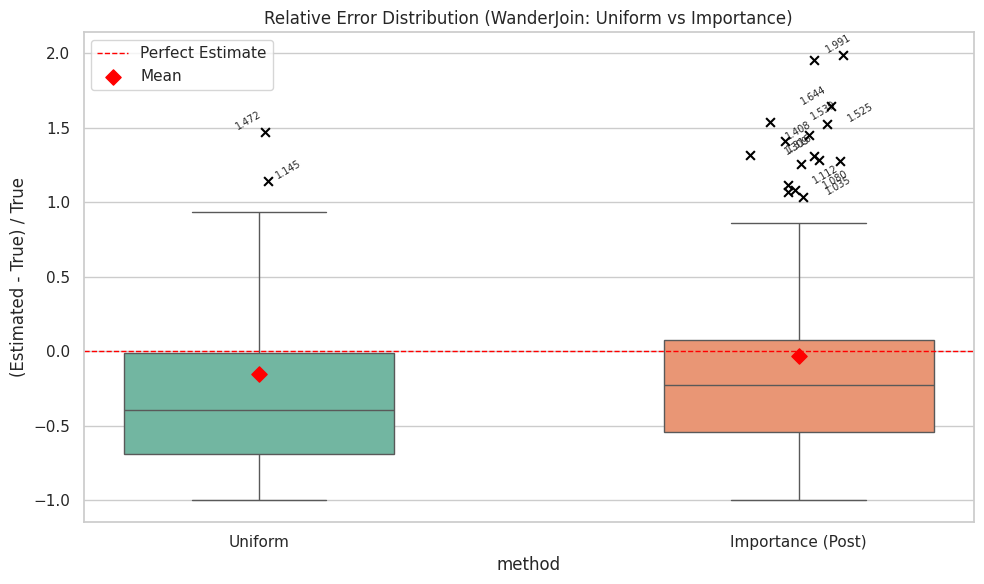


====== Out-of-range Outliers (not plotted) ======

Method: Uniform  (count=9)
  query_cycle_6_138.graph: 2.184034
  query_cycle_6_145.graph: 3.389413
  query_cycle_6_186.graph: 8.315280
  query_cycle_6_54.graph: 8.174902
  query_cycle_8_225.graph: 2.193290
  query_cycle_8_326.graph: 2.265202
  query_path_4_0.graph: 9.813182
  query_path_6_92.graph: 3.859614
  query_path_6_94.graph: 4.012432

Method: Importance (Post)  (count=9)
  query_cycle_6_132.graph: 3.072597
  query_cycle_6_165.graph: 3.295612
  query_cycle_6_178.graph: 2.564075
  query_path_4_0.graph: 4.838135
  query_path_6_101.graph: 3.952918
  query_path_6_110.graph: 4.229166
  query_path_6_119.graph: 3.128885
  query_path_6_42.graph: 3.425775
  query_path_8_179.graph: 3.751664


/tmp/ipykernel_213094/2533884127.py:535: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.barplot(x="method", y="AbsRelativeError", data=mape, palette="viridis")


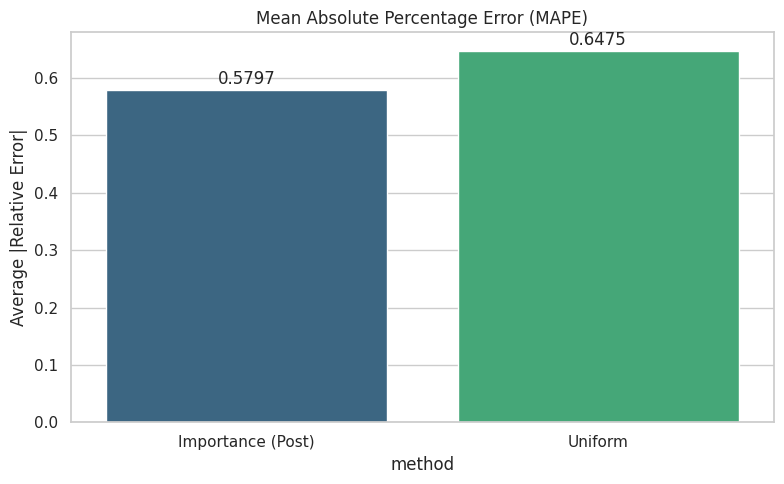

/tmp/ipykernel_213094/2533884127.py:547: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax3 = sns.barplot(x="method", y="n_post", data=avg_samples, palette="Blues_d")


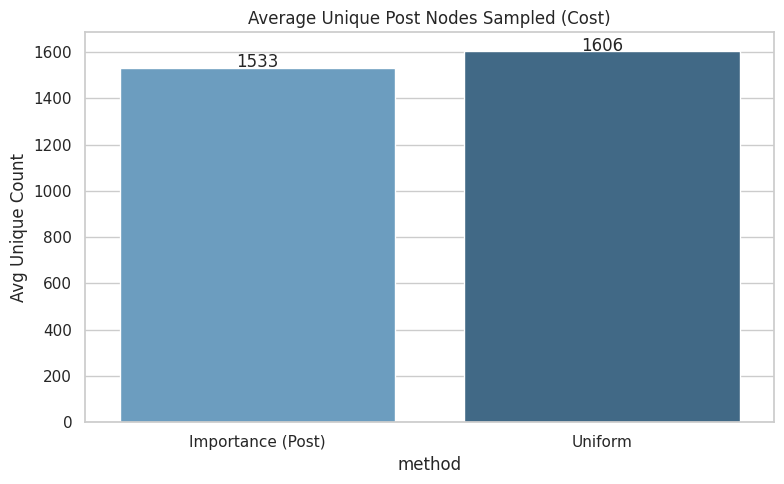


====== Statistical Summary ======
                  Qerror                                               \
                   count      mean       std  min       25%       50%   
method                                                                  
Importance (Post)  246.0 -0.030334  0.910625 -1.0 -0.541588 -0.227310   
Uniform            246.0 -0.151790  1.217204 -1.0 -0.694392 -0.392636   

                                      n_post                                 \
                        75%       max  count         mean          std  min   
method                                                                        
Importance (Post)  0.077052  4.838135  246.0  1533.048780  2010.277826  4.0   
Uniform           -0.011848  9.813182  246.0  1605.674797  2081.002837  4.0   

                                                   
                     25%     50%      75%     max  
method                                             
Importance (Post)  266.5   989.5  1504.00  7918

In [ ]:
# 2. 绘制对比图
# plot_results(df_results)
plot_results(df_results, allowed_range=(-1.0, 1.0))